# Master Thesis SAE Analysis: Mixed-5700 vs GUS-Net

This notebook is a **full comparative SAE study** across two different bias-analysis settings already present in your project:

1. **Sentence-level mixed-5700 setup** built from `dataset/bias_sentences_mixed_5700.json` and associated with the classic BERT/GPT-2 bias pipelines.
2. **Token-level GUS-Net setup** built from `dataset/gus_dataset_clean.json` and associated with the fine-tuned GUS-Net models.

The notebook is intentionally ordered like a thesis chapter:
- first: standard/base-model mixed-5700 analysis;
- second: GUS-Net token-level analysis;
- final: unified comparison tables and interpretation.

This means the comparison is not only **base vs fine-tuned**, but also **sentence-level bias detection vs token-level span-level bias detection**.

Outputs are saved under `notebooks/sae_master_thesis_results/`.

In [65]:
from __future__ import annotations

import gc
import json
import random
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from transformers import AutoConfig, AutoModel, AutoModelForTokenClassification, AutoTokenizer

ROOT = Path.cwd()
if not (ROOT / 'attention_app').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from attention_app.bias.counterfactual import find_swappable_terms, generate_counterfactual

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
sns.set_theme(style='whitegrid')

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def infer_model_family(config) -> str:
    model_type = getattr(config, 'model_type', '')
    if model_type == 'gpt2':
        return 'gpt2'
    if model_type in {'bert', 'roberta', 'distilbert'}:
        return model_type
    name = getattr(config, '_name_or_path', '').lower()
    if 'gpt2' in name:
        return 'gpt2'
    return 'bert'

def build_tokenizer(model_name: str, family: str):
    kwargs = {'use_fast': True}
    if family == 'gpt2':
        kwargs['add_prefix_space'] = True
    tokenizer = AutoTokenizer.from_pretrained(model_name, **kwargs)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token or tokenizer.sep_token
    return tokenizer

def save_json(path: Path, payload: dict):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

def fit_probe(x_train, y_train, x_test, y_test, label: str):
    clf = LogisticRegression(max_iter=800, class_weight='balanced', solver='liblinear', random_state=42)
    clf.fit(x_train, y_train)
    probs = clf.predict_proba(x_test)[:, 1]
    preds = (probs >= 0.5).astype(int)
    metrics = {
        f'{label}_auc': roc_auc_score(y_test, probs) if len(np.unique(y_test)) > 1 else float('nan'),
        f'{label}_ap': average_precision_score(y_test, probs) if len(np.unique(y_test)) > 1 else float('nan'),
        f'{label}_f1': f1_score(y_test, preds, zero_division=0),
        f'{label}_precision': precision_score(y_test, preds, zero_division=0),
        f'{label}_recall': recall_score(y_test, preds, zero_division=0),
        f'{label}_accuracy': accuracy_score(y_test, preds),
    }
    return clf, metrics

def benjamini_hochberg(p_values: np.ndarray) -> np.ndarray:
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adjusted = np.empty(n, dtype=float)
    cumulative = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        candidate = ranked[i] * n / rank
        cumulative = min(cumulative, candidate)
        adjusted[i] = cumulative
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adjusted, 0.0, 1.0)
    return out

def activation_frequency(feats: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    return (feats > eps).mean(axis=0)

@dataclass
class SAEArtifacts:
    sae: nn.Module
    mean: torch.Tensor
    std: torch.Tensor
    history: list[dict]


Device: cuda


In [66]:
# Set experiment paths, global hyperparameters, model lists, and sweep settings for the full study

seed_everything(42)

DATA_MIXED_PATH = ROOT / 'dataset' / 'bias_sentences_mixed_5700.json'
DATA_GUS_PATH = ROOT / 'dataset' / 'gus_dataset_clean.json'
OUT_DIR = ROOT / 'notebooks' / 'sae_master_thesis_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_LENGTH = 128
TRAIN_SENTENCE_LIMIT = 1200
TEST_SENTENCE_LIMIT = 400
COUNTERFACTUAL_LIMIT = 120
INTERVENTION_LIMIT = 50
TOP_K_FEATURES = 15
TOP_K_EXAMPLES = 5
EXPANSION = 8
L1_COEFF = 5e-4
SAE_LR = 3e-4
SAE_BATCH_SIZE = 256
SAE_EPOCHS = 75
VAL_FRACTION = 0.1
DEFAULT_LAYER_IDX = 9

RUN_LAYER_SWEEP = True
LAYER_SWEEP_LAYERS = [0,1,2,3,4,5,6,7,8,9,10,11]
LAYER_SWEEP_SENTENCES = 180
LAYER_SWEEP_EPOCHS = 50

MIXED_MODELS = [
    {'label': 'BERT Base Mixed5700', 'name': 'bert-base-uncased', 'kind': 'mixed5700', 'dataset_kind': 'mixed5700'},
    {'label': 'GPT-2 Base Mixed5700', 'name': 'gpt2', 'kind': 'mixed5700', 'dataset_kind': 'mixed5700'},
]

GUS_MODELS = [
    {'label': 'GUS-Net BERT', 'name': 'pinthoz/gus-net-bert', 'kind': 'gusnet', 'dataset_kind': 'gusnet'},
    {'label': 'GUS-Net GPT-2', 'name': 'pinthoz/gus-net-gpt2', 'kind': 'gusnet', 'dataset_kind': 'gusnet'},
]

ALL_MODELS = MIXED_MODELS + GUS_MODELS

LABEL_COLUMNS = ['B-STEREO', 'I-STEREO', 'B-GEN', 'I-GEN', 'B-UNFAIR', 'I-UNFAIR']


## Dataset Loaders

The notebook supports both:
- `bias_sentences_mixed_5700.json` for the sentence-level mixed setup;
- `gus_dataset_clean.json` for the token-level GUS-Net setup.

In [67]:
# Load the mixed-5700 and GUS datasets and create reproducible train and test splits for both settings

def load_mixed_5700_dataset(path: Path) -> list[dict]:
    with open(path, 'r', encoding='utf-8') as f:
        payload = json.load(f)
    entries = payload['entries']
    rows = []
    for item in entries:
        rows.append({
            'row_id': int(item['id']),
            'text': item['text'],
            'has_bias': int(bool(item['has_bias'])),
            'bias_type': item.get('bias_type'),
            'bias_description': item.get('bias_description'),
            'source': item.get('source'),
        })
    return rows

def load_gus_clean_dataset(path: Path) -> list[dict]:
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for idx, item in enumerate(data):
        tags = item['ner_tags']
        has_bias = any(any(tag != 'O' for tag in token_tags) for token_tags in tags)
        bias_types = sorted({tag.replace('B-', '').replace('I-', '') for token_tags in tags for tag in token_tags if tag != 'O'})
        rows.append({
            'row_id': idx,
            'text': item['text_str'],
            'ner_tags': tags,
            'has_bias': int(has_bias),
            'bias_types': bias_types,
        })
    return rows

def build_sentence_splits(rows: list[dict], train_limit=TRAIN_SENTENCE_LIMIT, test_limit=TEST_SENTENCE_LIMIT):
    df = pd.DataFrame(rows)
    train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['has_bias'], random_state=42)
    train_df = train_df.sample(n=min(train_limit, len(train_df)), random_state=42).reset_index(drop=True) if train_limit is not None else train_df.reset_index(drop=True)
    test_df = test_df.sample(n=min(test_limit, len(test_df)), random_state=42).reset_index(drop=True) if test_limit is not None else test_df.reset_index(drop=True)
    return train_df, test_df

mixed_rows = load_mixed_5700_dataset(DATA_MIXED_PATH)
gus_rows = load_gus_clean_dataset(DATA_GUS_PATH)
mixed_train_df, mixed_test_df = build_sentence_splits(mixed_rows)
gus_train_df, gus_test_df = build_sentence_splits(gus_rows)

print('Mixed-5700:', len(mixed_train_df), len(mixed_test_df))
print(mixed_train_df['has_bias'].value_counts().to_dict())
print('GUS clean:', len(gus_train_df), len(gus_test_df))
print(gus_train_df['has_bias'].value_counts().to_dict())

Mixed-5700: 1200 400
{0: 611, 1: 589}
GUS clean: 1200 400
{1: 1099, 0: 101}


## SAE Utilities

Shared SAE code used by both the mixed-5700 and GUS-Net analyses.

In [68]:
# Define the sparse autoencoder, normalization utilities, training loop, encoding step, and feature significance analysis

class SparseAutoencoder(nn.Module):
    def __init__(self, d_input: int, d_hidden: int, l1_coeff: float = 1e-3):
        super().__init__()
        self.d_input = d_input
        self.d_hidden = d_hidden
        self.l1_coeff = l1_coeff
        self.encoder = nn.Linear(d_input, d_hidden)
        self.decoder = nn.Linear(d_hidden, d_input, bias=False)
        self.b_dec = nn.Parameter(torch.zeros(d_input))
        nn.init.kaiming_uniform_(self.encoder.weight)
        nn.init.zeros_(self.encoder.bias)
        with torch.no_grad():
            self.decoder.weight.data = F.normalize(self.decoder.weight.data, dim=0)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.encoder(x - self.b_dec))

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z) + self.b_dec

    def forward(self, x: torch.Tensor):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

    def loss_dict(self, x: torch.Tensor):
        x_hat, z = self.forward(x)
        mse = F.mse_loss(x_hat, x)
        l1 = self.l1_coeff * z.abs().mean()
        l0 = (z > 1e-8).float().sum(dim=-1).mean()
        return {'loss': mse + l1, 'mse': mse.detach(), 'l1': l1.detach(), 'l0': l0.detach()}

def normalize_train_test(train_tensor: torch.Tensor, test_tensor: torch.Tensor):
    mean = train_tensor.mean(dim=0)
    std = train_tensor.std(dim=0).clamp(min=1e-6)
    return (train_tensor - mean) / std, (test_tensor - mean) / std, mean, std

def train_sae(train_tensor: torch.Tensor) -> SAEArtifacts:
    n = len(train_tensor)
    split = max(1, int(n * (1 - VAL_FRACTION)))
    perm = torch.randperm(n)
    train_idx = perm[:split]
    val_idx = perm[split:]
    if len(val_idx) == 0:
        val_idx = train_idx[: min(512, len(train_idx))]
    x_train = train_tensor[train_idx]
    x_val = train_tensor[val_idx]
    d_input = x_train.shape[1]
    d_hidden = d_input * EXPANSION
    sae = SparseAutoencoder(d_input, d_hidden, l1_coeff=L1_COEFF).to(DEVICE)
    opt = torch.optim.Adam(sae.parameters(), lr=SAE_LR)
    loader = DataLoader(TensorDataset(x_train), batch_size=SAE_BATCH_SIZE, shuffle=True, drop_last=False)
    history = []
    best_state = None
    best_val = float('inf')
    for epoch in range(SAE_EPOCHS):
        sae.train()
        accum = {'loss': 0.0, 'mse': 0.0, 'l1': 0.0, 'l0': 0.0}
        n_batches = 0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            stats_dict = sae.loss_dict(batch)
            stats_dict['loss'].backward()
            opt.step()
            opt.zero_grad(set_to_none=True)
            with torch.no_grad():
                sae.decoder.weight.data = F.normalize(sae.decoder.weight.data, dim=0)
            for key in accum:
                accum[key] += float(stats_dict[key].detach().cpu())
            n_batches += 1
        sae.eval()
        with torch.no_grad():
            val_stats = sae.loss_dict(x_val.to(DEVICE))
        row = {
            'epoch': epoch + 1,
            'train_loss': accum['loss'] / n_batches,
            'train_mse': accum['mse'] / n_batches,
            'train_l1': accum['l1'] / n_batches,
            'train_l0': accum['l0'] / n_batches,
            'val_loss': float(val_stats['loss'].cpu()),
            'val_mse': float(val_stats['mse'].cpu()),
            'val_l1': float(val_stats['l1'].cpu()),
            'val_l0': float(val_stats['l0'].cpu()),
        }
        history.append(row)
        print(f"Epoch {row['epoch']:02d} | train_loss={row['train_loss']:.4f} | val_loss={row['val_loss']:.4f} | val_l0={row['val_l0']:.1f}")
        if row['val_loss'] < best_val:
            best_val = row['val_loss']
            best_state = {k: v.detach().cpu().clone() for k, v in sae.state_dict().items()}
    sae.load_state_dict(best_state)
    return SAEArtifacts(sae=sae.eval(), mean=None, std=None, history=history)

def encode_with_sae(artifacts: SAEArtifacts, tensor: torch.Tensor) -> np.ndarray:
    with torch.no_grad():
        _, z = artifacts.sae(tensor.to(DEVICE))
    return z.cpu().numpy()

def analyse_features_binary(train_feats: np.ndarray, train_y: np.ndarray, test_feats: np.ndarray, test_y: np.ndarray):
    b_mean = test_feats[test_y == 1].mean(axis=0)
    n_mean = test_feats[test_y == 0].mean(axis=0)
    diff = b_mean - n_mean
    freq = activation_frequency(test_feats)
    p_values = np.ones(test_feats.shape[1], dtype=float)
    effect_sizes = np.zeros(test_feats.shape[1], dtype=float)
    for i in tqdm(range(test_feats.shape[1]), desc='Feature tests', leave=False):
        x1 = test_feats[test_y == 1, i]
        x0 = test_feats[test_y == 0, i]
        if (x1 > 1e-8).sum() + (x0 > 1e-8).sum() == 0:
            continue
        stat, p = stats.mannwhitneyu(x1, x0, alternative='two-sided')
        p_values[i] = p
        effect_sizes[i] = 1 - 2 * stat / (len(x1) * len(x0))
    q_values = benjamini_hochberg(p_values)
    feature_df = pd.DataFrame({
        'feature_idx': np.arange(test_feats.shape[1]),
        'biased_mean': b_mean,
        'neutral_mean': n_mean,
        'diff': diff,
        'abs_diff': np.abs(diff),
        'effect_size': effect_sizes,
        'p_value': p_values,
        'q_value': q_values,
        'activation_freq': freq,
    })
    feature_df['significant'] = (feature_df['q_value'] < 0.05) & (feature_df['activation_freq'] > 0.01)
    top_features = feature_df.sort_values(['significant', 'abs_diff'], ascending=[False, False]).head(TOP_K_FEATURES).copy()
    return feature_df, top_features

## Part I — Mixed-5700 Sentence-Level Analysis

This section is for the **classic bias classification setup** trained on `dataset/bias_sentences_mixed_5700.json`.
Here the target is sentence-level `has_bias`, so the SAE is trained on **sentence representations**, not token labels.

This matches your older BERT/GPT-2 bias experiments much better than using the GUS token-level dataset here.

In [69]:
# Define all functions required for the sentence-level mixed-5700 SAE analysis, including counterfactual and intervention evaluation

def load_mixed_model_bundle(spec: dict):
    config = AutoConfig.from_pretrained(spec['name'])
    family = infer_model_family(config)
    tokenizer = build_tokenizer(spec['name'], family)
    model = AutoModel.from_pretrained(spec['name']).to(DEVICE).eval()
    return {'config': config, 'family': family, 'tokenizer': tokenizer, 'model': model, 'kind': spec['kind'], 'dataset_kind': spec['dataset_kind']}

def sentence_hidden_mean(text: str, bundle: dict, layer_idx: int):
    tokenizer = bundle['tokenizer']
    model = bundle['model']
    encoded = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LENGTH)
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = model(**encoded, output_hidden_states=True, return_dict=True)
    hidden = outputs.hidden_states[layer_idx + 1][0].detach().cpu()
    input_ids = encoded['input_ids'][0].detach().cpu().tolist()
    special_mask = tokenizer.get_special_tokens_mask(input_ids, already_has_special_tokens=True)
    attn_mask = encoded['attention_mask'][0].detach().cpu().numpy().astype(bool)
    valid = np.array([(m and (s == 0)) for m, s in zip(attn_mask, special_mask)], dtype=bool)
    if valid.sum() == 0:
        return hidden.mean(dim=0)
    return hidden[valid].mean(dim=0)

def extract_sentence_activations(frame: pd.DataFrame, bundle: dict, layer_idx: int, desc: str):
    acts = []
    meta_rows = []
    for sample in tqdm(frame.to_dict(orient='records'), desc=desc):
        vec = sentence_hidden_mean(sample['text'], bundle, layer_idx)
        acts.append(vec)
        meta_rows.append({
            'row_id': sample['row_id'],
            'text': sample['text'],
            'has_bias': int(sample['has_bias']),
            'bias_type': sample.get('bias_type'),
            'source': sample.get('source'),
        })
    return torch.stack(acts), pd.DataFrame(meta_rows)

def sentence_feature_vector_mixed(text: str, bundle: dict, artifacts: SAEArtifacts, layer_idx: int, feature_ablation: list[int] | None = None):
    tokenizer = bundle['tokenizer']
    model = bundle['model']
    family = bundle['family']
    encoded = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LENGTH)
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    handle = None
    if feature_ablation:
        if family in {'bert', 'roberta', 'distilbert'}:
            layer_module = model.encoder.layer[layer_idx].output
        else:
            layer_module = model.h[layer_idx]
        feature_ids_t = torch.tensor(feature_ablation, dtype=torch.long, device=DEVICE)
        def hook_fn(_module, _inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            x_norm = (hidden - artifacts.mean.to(hidden.device)) / artifacts.std.to(hidden.device)
            z = artifacts.sae.encode(x_norm)
            z[..., feature_ids_t] = 0.0
            x_new = artifacts.sae.decode(z) * artifacts.std.to(hidden.device) + artifacts.mean.to(hidden.device)
            if isinstance(output, tuple):
                out = list(output)
                out[0] = x_new
                return tuple(out)
            return x_new
        handle = layer_module.register_forward_hook(hook_fn)
    try:
        with torch.no_grad():
            outputs = model(**encoded, output_hidden_states=True, return_dict=True)
    finally:
        if handle is not None:
            handle.remove()
    hidden = outputs.hidden_states[layer_idx + 1][0].detach().cpu()
    input_ids = encoded['input_ids'][0].detach().cpu().tolist()
    special_mask = tokenizer.get_special_tokens_mask(input_ids, already_has_special_tokens=True)
    attn_mask = encoded['attention_mask'][0].detach().cpu().numpy().astype(bool)
    valid = np.array([(m and (s == 0)) for m, s in zip(attn_mask, special_mask)], dtype=bool)
    pooled = hidden[valid].mean(dim=0) if valid.sum() else hidden.mean(dim=0)
    x = ((pooled - artifacts.mean) / artifacts.std).unsqueeze(0)
    with torch.no_grad():
        z = artifacts.sae.encode(x.to(DEVICE)).cpu().numpy()[0]
    return z

def run_mixed_analysis(spec: dict, train_df: pd.DataFrame, test_df: pd.DataFrame, layer_idx: int = DEFAULT_LAYER_IDX):
    print(f"Running mixed-5700 SAE analysis for {spec['label']}")
    bundle = load_mixed_model_bundle(spec)
    model_dir = OUT_DIR / spec['label'].lower().replace(' ', '_').replace('-', '_')
    model_dir.mkdir(parents=True, exist_ok=True)
    train_acts, train_meta = extract_sentence_activations(train_df, bundle, layer_idx, f"Train sentence activations — {spec['label']}")
    test_acts, test_meta = extract_sentence_activations(test_df, bundle, layer_idx, f"Test sentence activations — {spec['label']}")
    train_norm, test_norm, mean, std = normalize_train_test(train_acts.float(), test_acts.float())
    artifacts = train_sae(train_norm)
    artifacts.mean = mean
    artifacts.std = std
    hist_df = pd.DataFrame(artifacts.history)
    hist_df.to_csv(model_dir / 'sae_training_history.csv', index=False)
    train_feats = encode_with_sae(artifacts, train_norm)
    test_feats = encode_with_sae(artifacts, test_norm)
    feature_df, top_features = analyse_features_binary(train_feats, train_meta['has_bias'].to_numpy(), test_feats, test_meta['has_bias'].to_numpy())
    feature_df.to_csv(model_dir / 'feature_statistics.csv', index=False)
    top_features.to_csv(model_dir / 'top_features.csv', index=False)
    probe, probe_metrics = fit_probe(train_feats, train_meta['has_bias'].to_numpy(), test_feats, test_meta['has_bias'].to_numpy(), 'sentence_probe')
    example_rows = []
    for feat_idx in top_features['feature_idx'].tolist():
        acts = test_feats[:, feat_idx]
        top_idx = np.argsort(acts)[::-1][:TOP_K_EXAMPLES]
        direction = 'biased' if float(top_features.loc[top_features['feature_idx'] == feat_idx, 'diff'].iloc[0]) > 0 else 'neutral'
        for rank, row_idx in enumerate(top_idx, 1):
            row = test_meta.iloc[row_idx]
            example_rows.append({
                'feature_idx': feat_idx,
                'rank': rank,
                'direction': direction,
                'activation': float(acts[row_idx]),
                'has_bias': int(row['has_bias']),
                'bias_type': row['bias_type'],
                'source': row['source'],
                'text': row['text'],
            })
    example_df = pd.DataFrame(example_rows)
    example_df.to_csv(model_dir / 'top_feature_examples.csv', index=False)
    cf_rows = []
    for sample in tqdm(test_df.to_dict(orient='records')[:COUNTERFACTUAL_LIMIT], desc='Counterfactual analysis', leave=False):
        swaps = find_swappable_terms(sample['text'])
        if not swaps:
            continue
        cf_text, applied = generate_counterfactual(sample['text'], swaps)
        if cf_text == sample['text']:
            continue
        orig_vec = sentence_feature_vector_mixed(sample['text'], bundle, artifacts, layer_idx)
        cf_vec = sentence_feature_vector_mixed(cf_text, bundle, artifacts, layer_idx)
        probe_orig = float(probe.predict_proba(orig_vec.reshape(1, -1))[0, 1])
        probe_cf = float(probe.predict_proba(cf_vec.reshape(1, -1))[0, 1])
        delta = orig_vec - cf_vec
        cf_rows.append({
            'text': sample['text'],
            'counterfactual': cf_text,
            'swaps': json.dumps(applied, ensure_ascii=False),
            'max_abs_delta': float(np.abs(delta).max()),
            'probe_orig': probe_orig,
            'probe_cf': probe_cf,
            'probe_delta': probe_orig - probe_cf,
        })
    cf_df = pd.DataFrame(cf_rows).sort_values('max_abs_delta', ascending=False) if cf_rows else pd.DataFrame()
    if len(cf_df):
        cf_df.to_csv(model_dir / 'counterfactual_pairs.csv', index=False)
    active_pool = feature_df.loc[feature_df['activation_freq'] > 0.01, 'feature_idx'].to_numpy()
    top_ids = top_features['feature_idx'].head(min(8, len(top_features))).tolist()
    intervention_rows = []
    if len(active_pool) and len(top_ids):
        random_ids = np.random.choice(active_pool, size=min(len(top_ids), len(active_pool)), replace=False).tolist()
        for sample in tqdm(test_df.head(min(INTERVENTION_LIMIT, len(test_df))).to_dict(orient='records'), desc='Causal intervention', leave=False):
            base_vec = sentence_feature_vector_mixed(sample['text'], bundle, artifacts, layer_idx)
            sae_vec = sentence_feature_vector_mixed(sample['text'], bundle, artifacts, layer_idx, feature_ablation=top_ids)
            rand_vec = sentence_feature_vector_mixed(sample['text'], bundle, artifacts, layer_idx, feature_ablation=random_ids)
            probe_base = float(probe.predict_proba(base_vec.reshape(1, -1))[0, 1])
            probe_sae = float(probe.predict_proba(sae_vec.reshape(1, -1))[0, 1])
            probe_rand = float(probe.predict_proba(rand_vec.reshape(1, -1))[0, 1])
            intervention_rows.append({
                'text': sample['text'],
                'has_bias': int(sample['has_bias']),
                'probe_base': probe_base,
                'probe_sae_ablated': probe_sae,
                'probe_random_ablated': probe_rand,
                'delta_probe_sae': probe_base - probe_sae,
                'delta_probe_random': probe_base - probe_rand,
            })
    intervention_df = pd.DataFrame(intervention_rows)
    if len(intervention_df):
        intervention_df.to_csv(model_dir / 'intervention_results.csv', index=False)
    summary = {
        'model_label': spec['label'],
        'model_name': spec['name'],
        'analysis_group': 'mixed5700',
        'family': bundle['family'],
        'hidden_size': int(bundle['config'].hidden_size),
        'analysis_layer': int(layer_idx),
        'n_train_sentences': int(len(train_df)),
        'n_test_sentences': int(len(test_df)),
        'representation_level': 'sentence',
        'n_significant_features': int(feature_df['significant'].sum()),
        'top_abs_diff': float(feature_df['abs_diff'].max()),
        'mean_activation_freq': float(feature_df['activation_freq'].mean()),
        'best_val_loss': float(hist_df['val_loss'].min()),
        'best_val_l0': float(hist_df.loc[hist_df['val_loss'].idxmin(), 'val_l0']),
        **probe_metrics,
        'counterfactual_pairs': int(len(cf_df)),
        'cf_mean_max_abs_delta': float(cf_df['max_abs_delta'].mean()) if len(cf_df) else float('nan'),
        'cf_mean_probe_delta': float(cf_df['probe_delta'].mean()) if len(cf_df) else float('nan'),
        'intervention_examples': int(len(intervention_df)),
        'mean_delta_probe_sae': float(intervention_df['delta_probe_sae'].mean()) if len(intervention_df) else float('nan'),
        'mean_delta_probe_random': float(intervention_df['delta_probe_random'].mean()) if len(intervention_df) else float('nan'),
    }
    save_json(model_dir / 'summary.json', summary)
    cleanup_cuda()
    return {
        'bundle': bundle,
        'artifacts': artifacts,
        'history_df': hist_df,
        'feature_df': feature_df,
        'top_features': top_features,
        'example_df': example_df,
        'cf_df': cf_df,
        'intervention_df': intervention_df,
        'summary': summary,
    }

In [70]:
# Run the complete sentence-level SAE analysis for the base mixed-5700 models and save the resulting summaries

mixed_results = {}
for spec in MIXED_MODELS:
    mixed_results[spec['label']] = run_mixed_analysis(spec, mixed_train_df, mixed_test_df)

mixed_summary_df = pd.DataFrame([payload['summary'] for payload in mixed_results.values()])
mixed_summary_df.to_csv(OUT_DIR / 'mixed5700_summary.csv', index=False)
mixed_summary_df

Running mixed-5700 SAE analysis for BERT Base Mixed5700


c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model tha

Train sentence activations — BERT Base Mixed5700:   0%|          | 0/1200 [00:00<?, ?it/s]

Test sentence activations — BERT Base Mixed5700:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 01 | train_loss=6.5487 | val_loss=5.0689 | val_l0=3075.2
Epoch 02 | train_loss=4.3461 | val_loss=3.9749 | val_l0=3075.5
Epoch 03 | train_loss=3.2727 | val_loss=3.4134 | val_l0=3076.8
Epoch 04 | train_loss=2.6810 | val_loss=3.0280 | val_l0=3076.2
Epoch 05 | train_loss=2.2392 | val_loss=2.7575 | val_l0=3076.5
Epoch 06 | train_loss=1.9282 | val_loss=2.5591 | val_l0=3076.6
Epoch 07 | train_loss=1.6862 | val_loss=2.4072 | val_l0=3076.1
Epoch 08 | train_loss=1.4990 | val_loss=2.2969 | val_l0=3076.0
Epoch 09 | train_loss=1.3237 | val_loss=2.1993 | val_l0=3075.7
Epoch 10 | train_loss=1.1944 | val_loss=2.1216 | val_l0=3075.6
Epoch 11 | train_loss=1.0776 | val_loss=2.0610 | val_l0=3075.5
Epoch 12 | train_loss=0.9857 | val_loss=2.0040 | val_l0=3074.9
Epoch 13 | train_loss=0.9097 | val_loss=1.9569 | val_l0=3074.9
Epoch 14 | train_loss=0.8320 | val_loss=1.9153 | val_l0=3073.5
Epoch 15 | train_loss=0.7707 | val_loss=1.8771 | val_l0=3073.0
Epoch 16 | train_loss=0.7057 | val_loss=1.8446 | val_l0

...

Epoch 01 | train_loss=6.5276 | val_loss=5.3982 | val_l0=3075.7
Epoch 02 | train_loss=4.4853 | val_loss=4.3541 | val_l0=3078.3
Epoch 03 | train_loss=3.4464 | val_loss=3.8166 | val_l0=3077.7
Epoch 04 | train_loss=2.8373 | val_loss=3.4183 | val_l0=3077.3
Epoch 05 | train_loss=2.3861 | val_loss=3.1318 | val_l0=3074.8
Epoch 06 | train_loss=2.0561 | val_loss=2.9254 | val_l0=3074.5
Epoch 07 | train_loss=1.7995 | val_loss=2.7624 | val_l0=3074.8
Epoch 08 | train_loss=1.5766 | val_loss=2.6312 | val_l0=3074.3
Epoch 09 | train_loss=1.4052 | val_loss=2.5272 | val_l0=3074.9
Epoch 10 | train_loss=1.2526 | val_loss=2.4374 | val_l0=3074.3
Epoch 11 | train_loss=1.1337 | val_loss=2.3682 | val_l0=3073.0
Epoch 12 | train_loss=1.0250 | val_loss=2.3011 | val_l0=3073.6
Epoch 13 | train_loss=0.9435 | val_loss=2.2492 | val_l0=3073.7
Epoch 14 | train_loss=0.8599 | val_loss=2.1983 | val_l0=3073.9
Epoch 15 | train_loss=0.7883 | val_loss=2.1567 | val_l0=3074.3
Epoch 16 | train_loss=0.7281 | val_loss=2.1173 | val_l0

Feature tests:   0%|          | 0/6144 [00:00<?, ?it/s]

Counterfactual analysis:   0%|          | 0/120 [00:00<?, ?it/s]

Causal intervention:   0%|          | 0/50 [00:00<?, ?it/s]

,model_label,model_name,analysis_group,family,hidden_size,analysis_layer,n_train_sentences,n_test_sentences,representation_level,n_significant_features,...,sentence_probe_f1,sentence_probe_precision,sentence_probe_recall,sentence_probe_accuracy,counterfactual_pairs,cf_mean_max_abs_delta,cf_mean_probe_delta,intervention_examples,mean_delta_probe_sae,mean_delta_probe_random
0,BERT Base Mixed5700,bert-base-uncased,mixed5700,bert,768,9,1200,400,sentence,2964,...,0.943590,0.924623,0.963351,0.945,39,1.244818,-0.010845,50,0.036908,0.043828
1,GPT-2 Base Mixed5700,gpt2,mixed5700,gpt2,768,9,1200,400,sentence,2858,...,0.947917,0.943005,0.952880,0.950,39,1.335400,-0.010573,50,-0.013079,-0.020337


## Part II — GUS-Net Token-Level Analysis

This section matches the **actual GUS-Net training setup** on `gus_dataset_clean.json`.
Here the SAE is applied to **token-level hidden states**, which is much more appropriate for span-level bias detection.

In [71]:
# Define all functions required for the token-level GUS-Net SAE analysis, including token aggregation, counterfactual tests, and native score ablations

def load_gus_bundle(spec: dict):
    config = AutoConfig.from_pretrained(spec['name'])
    family = infer_model_family(config)
    tokenizer = build_tokenizer(spec['name'], family)
    model = AutoModelForTokenClassification.from_pretrained(spec['name']).to(DEVICE).eval()
    return {'config': config, 'family': family, 'tokenizer': tokenizer, 'model': model, 'kind': spec['kind'], 'dataset_kind': spec['dataset_kind']}

def bias_vector_from_token_tags(token_tags: list[str]) -> list[int]:
    label2id = {
        'B-STEREO': 0, 'I-STEREO': 1,
        'B-GEN': 2, 'I-GEN': 3,
        'B-UNFAIR': 4, 'I-UNFAIR': 5,
    }
    vec = [0] * len(LABEL_COLUMNS)
    for tag in token_tags:
        if tag in label2id:
            vec[label2id[tag]] = 1
    return vec

def tokenize_and_align_gus(sample: dict, tokenizer, max_length: int = 128):
    words = sample['text'].split()
    tags = sample['ner_tags']
    min_len = min(len(words), len(tags))
    words = words[:min_len]
    tags = tags[:min_len]
    encoded = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt',
    )
    word_ids = encoded.word_ids(batch_index=0)
    aligned = []
    prev_word_id = None
    for word_id in word_ids:
        if word_id is None:
            aligned.append([-100] * len(LABEL_COLUMNS))
        elif word_id == prev_word_id:
            aligned.append([-100] * len(LABEL_COLUMNS))
        else:
            aligned.append(bias_vector_from_token_tags(tags[word_id]))
        prev_word_id = word_id
    return encoded, aligned

def sentence_bias_score_from_logits(logits: torch.Tensor) -> torch.Tensor:
    probs = torch.sigmoid(logits.float())
    if probs.shape[-1] >= 7:
        probs = probs[..., 1:7]
    stereo = torch.max(probs[..., 0], probs[..., 1])
    gen = torch.max(probs[..., 2], probs[..., 3])
    unfair = torch.max(probs[..., 4], probs[..., 5])
    return torch.stack([stereo, gen, unfair], dim=-1).max(dim=-1).values.max(dim=-1).values

def get_gus_layer_module(model, family: str, layer_idx: int):
    if family in {'bert', 'roberta', 'distilbert'}:
        base = model.bert if hasattr(model, 'bert') else model.roberta
        return base.encoder.layer[layer_idx].output
    if family == 'gpt2':
        return model.transformer.h[layer_idx]
    raise ValueError(f'Unsupported family: {family}')

def extract_token_activations_gus(frame: pd.DataFrame, bundle: dict, layer_idx: int, desc: str):
    tokenizer = bundle['tokenizer']
    model = bundle['model']
    activations = []
    records = []
    for sample in tqdm(frame.to_dict(orient='records'), desc=desc):
        encoded, aligned = tokenize_and_align_gus(sample, tokenizer, max_length=MAX_LENGTH)
        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = model(**encoded, output_hidden_states=True, return_dict=True)
        hidden = outputs.hidden_states[layer_idx + 1][0].detach().cpu()
        input_ids = encoded['input_ids'][0].detach().cpu().tolist()
        tokens = tokenizer.convert_ids_to_tokens(input_ids)
        for tok_idx, label_vec in enumerate(aligned):
            if label_vec[0] == -100:
                continue
            label_arr = np.array(label_vec, dtype=int)
            activations.append(hidden[tok_idx])
            records.append({
                'row_id': sample['row_id'],
                'text': sample['text'],
                'token': tokens[tok_idx],
                'token_idx': tok_idx,
                'bias_token': int(label_arr.sum() > 0),
                'sentence_has_bias': int(sample['has_bias']),
                'bias_types': [LABEL_COLUMNS[i].replace('B-', '').replace('I-', '') for i, v in enumerate(label_arr) if v == 1],
            })
    return torch.stack(activations), pd.DataFrame(records)

def aggregate_sentence_features(meta_df: pd.DataFrame, feats: np.ndarray):
    rows = []
    for row_id, sub_df in meta_df.groupby('row_id', sort=False):
        idxs = sub_df.index.to_numpy()
        rows.append({
            'row_id': row_id,
            'text': sub_df['text'].iloc[0],
            'sentence_has_bias': int(sub_df['sentence_has_bias'].iloc[0]),
            'feature_vec': feats[idxs].mean(axis=0),
        })
    return rows

def sentence_feature_vector_gus(text: str, bundle: dict, artifacts: SAEArtifacts, layer_idx: int, feature_ablation: list[int] | None = None):
    tokenizer = bundle['tokenizer']
    model = bundle['model']
    family = bundle['family']
    encoded = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LENGTH)
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    handle = None
    if feature_ablation:
        layer_module = get_gus_layer_module(model, family, layer_idx)
        feature_ids_t = torch.tensor(feature_ablation, dtype=torch.long, device=DEVICE)
        def hook_fn(_module, _inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            x_norm = (hidden - artifacts.mean.to(hidden.device)) / artifacts.std.to(hidden.device)
            z = artifacts.sae.encode(x_norm)
            z[..., feature_ids_t] = 0.0
            x_new = artifacts.sae.decode(z) * artifacts.std.to(hidden.device) + artifacts.mean.to(hidden.device)
            if isinstance(output, tuple):
                out = list(output)
                out[0] = x_new
                return tuple(out)
            return x_new
        handle = layer_module.register_forward_hook(hook_fn)
    try:
        with torch.no_grad():
            outputs = model(**encoded, output_hidden_states=True, return_dict=True)
    finally:
        if handle is not None:
            handle.remove()
    hidden = outputs.hidden_states[layer_idx + 1][0].detach().cpu()
    input_ids = encoded['input_ids'][0].detach().cpu().tolist()
    special_mask = tokenizer.get_special_tokens_mask(input_ids, already_has_special_tokens=True)
    attn_mask = encoded['attention_mask'][0].detach().cpu().numpy().astype(bool)
    valid = np.array([(m and (s == 0)) for m, s in zip(attn_mask, special_mask)], dtype=bool)
    if valid.sum() == 0:
        feat_vec = np.zeros(artifacts.sae.d_hidden, dtype=np.float32)
    else:
        x = (hidden[valid] - artifacts.mean) / artifacts.std
        with torch.no_grad():
            z = artifacts.sae.encode(x.to(DEVICE)).cpu().numpy()
        feat_vec = z.mean(axis=0)
    native_score = float(sentence_bias_score_from_logits(outputs.logits).item())
    return feat_vec, native_score

def run_gus_analysis(spec: dict, train_df: pd.DataFrame, test_df: pd.DataFrame, layer_idx: int = DEFAULT_LAYER_IDX):
    print('=' * 100)
    print(f"Running GUS-Net SAE analysis for {spec['label']}")
    print('=' * 100)
    bundle = load_gus_bundle(spec)
    model_dir = OUT_DIR / spec['label'].lower().replace(' ', '_').replace('-', '_')
    model_dir.mkdir(parents=True, exist_ok=True)
    train_acts, train_meta = extract_token_activations_gus(train_df, bundle, layer_idx, f"Train token activations — {spec['label']}")
    test_acts, test_meta = extract_token_activations_gus(test_df, bundle, layer_idx, f"Test token activations — {spec['label']}")
    train_norm, test_norm, mean, std = normalize_train_test(train_acts.float(), test_acts.float())
    artifacts = train_sae(train_norm)
    artifacts.mean = mean
    artifacts.std = std
    hist_df = pd.DataFrame(artifacts.history)
    hist_df.to_csv(model_dir / 'sae_training_history.csv', index=False)
    train_feats = encode_with_sae(artifacts, train_norm)
    test_feats = encode_with_sae(artifacts, test_norm)
    feature_df, top_features = analyse_features_binary(train_feats, train_meta['bias_token'].to_numpy(), test_feats, test_meta['bias_token'].to_numpy())
    feature_df.to_csv(model_dir / 'feature_statistics.csv', index=False)
    top_features.to_csv(model_dir / 'top_features.csv', index=False)
    token_probe, token_metrics = fit_probe(train_feats, train_meta['bias_token'].to_numpy(), test_feats, test_meta['bias_token'].to_numpy(), 'token_probe')
    train_sentence_rows = aggregate_sentence_features(train_meta, train_feats)
    test_sentence_rows = aggregate_sentence_features(test_meta, test_feats)
    x_train_sent = np.stack([r['feature_vec'] for r in train_sentence_rows])
    y_train_sent = np.array([r['sentence_has_bias'] for r in train_sentence_rows])
    x_test_sent = np.stack([r['feature_vec'] for r in test_sentence_rows])
    y_test_sent = np.array([r['sentence_has_bias'] for r in test_sentence_rows])
    sentence_probe, sentence_metrics = fit_probe(x_train_sent, y_train_sent, x_test_sent, y_test_sent, 'sentence_probe')
    example_rows = []
    for feat_idx in top_features['feature_idx'].tolist():
        acts = test_feats[:, feat_idx]
        top_idx = np.argsort(acts)[::-1][:TOP_K_EXAMPLES]
        direction = 'biased' if float(top_features.loc[top_features['feature_idx'] == feat_idx, 'diff'].iloc[0]) > 0 else 'neutral'
        for rank, row_idx in enumerate(top_idx, 1):
            row = test_meta.iloc[row_idx]
            example_rows.append({
                'feature_idx': feat_idx,
                'rank': rank,
                'direction': direction,
                'activation': float(acts[row_idx]),
                'token': row['token'],
                'bias_token': int(row['bias_token']),
                'bias_types': row['bias_types'],
                'text': row['text'],
            })
    example_df = pd.DataFrame(example_rows)
    example_df.to_csv(model_dir / 'top_feature_examples.csv', index=False)
    sentence_test_df = pd.DataFrame(test_sentence_rows)
    cf_rows = []
    for sample in tqdm(sentence_test_df.head(COUNTERFACTUAL_LIMIT).to_dict(orient='records'), desc='Counterfactual analysis', leave=False):
        swaps = find_swappable_terms(sample['text'])
        if not swaps:
            continue
        cf_text, applied = generate_counterfactual(sample['text'], swaps)
        if cf_text == sample['text']:
            continue
        orig_vec, native_orig = sentence_feature_vector_gus(sample['text'], bundle, artifacts, layer_idx)
        cf_vec, native_cf = sentence_feature_vector_gus(cf_text, bundle, artifacts, layer_idx)
        probe_orig = float(sentence_probe.predict_proba(orig_vec.reshape(1, -1))[0, 1])
        probe_cf = float(sentence_probe.predict_proba(cf_vec.reshape(1, -1))[0, 1])
        delta = orig_vec - cf_vec
        cf_rows.append({
            'text': sample['text'],
            'counterfactual': cf_text,
            'swaps': json.dumps(applied, ensure_ascii=False),
            'max_abs_delta': float(np.abs(delta).max()),
            'probe_orig': probe_orig,
            'probe_cf': probe_cf,
            'probe_delta': probe_orig - probe_cf,
            'native_orig': native_orig,
            'native_cf': native_cf,
            'native_delta': native_orig - native_cf,
        })
    cf_df = pd.DataFrame(cf_rows).sort_values('max_abs_delta', ascending=False) if cf_rows else pd.DataFrame()
    if len(cf_df):
        cf_df.to_csv(model_dir / 'counterfactual_pairs.csv', index=False)
    active_pool = feature_df.loc[feature_df['activation_freq'] > 0.01, 'feature_idx'].to_numpy()
    top_ids = top_features['feature_idx'].head(min(8, len(top_features))).tolist()
    intervention_rows = []
    if len(active_pool) and len(top_ids):
        random_ids = np.random.choice(active_pool, size=min(len(top_ids), len(active_pool)), replace=False).tolist()
        for sample in tqdm(test_df.head(min(INTERVENTION_LIMIT, len(test_df))).to_dict(orient='records'), desc='Causal intervention', leave=False):
            base_vec, native_base = sentence_feature_vector_gus(sample['text'], bundle, artifacts, layer_idx)
            sae_vec, native_sae = sentence_feature_vector_gus(sample['text'], bundle, artifacts, layer_idx, feature_ablation=top_ids)
            rand_vec, native_rand = sentence_feature_vector_gus(sample['text'], bundle, artifacts, layer_idx, feature_ablation=random_ids)
            probe_base = float(sentence_probe.predict_proba(base_vec.reshape(1, -1))[0, 1])
            probe_sae = float(sentence_probe.predict_proba(sae_vec.reshape(1, -1))[0, 1])
            probe_rand = float(sentence_probe.predict_proba(rand_vec.reshape(1, -1))[0, 1])
            intervention_rows.append({
                'text': sample['text'],
                'sentence_has_bias': int(sample['has_bias']),
                'probe_base': probe_base,
                'probe_sae_ablated': probe_sae,
                'probe_random_ablated': probe_rand,
                'delta_probe_sae': probe_base - probe_sae,
                'delta_probe_random': probe_base - probe_rand,
                'native_base': native_base,
                'native_sae_ablated': native_sae,
                'native_random_ablated': native_rand,
                'delta_native_sae': native_base - native_sae,
                'delta_native_random': native_base - native_rand,
            })
    intervention_df = pd.DataFrame(intervention_rows)
    if len(intervention_df):
        intervention_df.to_csv(model_dir / 'intervention_results.csv', index=False)
    summary = {
        'model_label': spec['label'],
        'model_name': spec['name'],
        'analysis_group': 'gusnet',
        'family': bundle['family'],
        'hidden_size': int(bundle['config'].hidden_size),
        'analysis_layer': int(layer_idx),
        'n_train_sentences': int(len(train_df)),
        'n_test_sentences': int(len(test_df)),
        'n_train_tokens': int(len(train_meta)),
        'n_test_tokens': int(len(test_meta)),
        'representation_level': 'token+sentence',
        'n_significant_features': int(feature_df['significant'].sum()),
        'top_abs_diff': float(feature_df['abs_diff'].max()),
        'mean_activation_freq': float(feature_df['activation_freq'].mean()),
        'best_val_loss': float(hist_df['val_loss'].min()),
        'best_val_l0': float(hist_df.loc[hist_df['val_loss'].idxmin(), 'val_l0']),
        **token_metrics,
        **sentence_metrics,
        'counterfactual_pairs': int(len(cf_df)),
        'cf_mean_max_abs_delta': float(cf_df['max_abs_delta'].mean()) if len(cf_df) else float('nan'),
        'cf_mean_probe_delta': float(cf_df['probe_delta'].mean()) if len(cf_df) else float('nan'),
        'cf_mean_native_delta': float(cf_df['native_delta'].mean()) if len(cf_df) else float('nan'),
        'intervention_examples': int(len(intervention_df)),
        'mean_delta_probe_sae': float(intervention_df['delta_probe_sae'].mean()) if len(intervention_df) else float('nan'),
        'mean_delta_probe_random': float(intervention_df['delta_probe_random'].mean()) if len(intervention_df) else float('nan'),
        'mean_delta_native_sae': float(intervention_df['delta_native_sae'].mean()) if len(intervention_df) else float('nan'),
        'mean_delta_native_random': float(intervention_df['delta_native_random'].mean()) if len(intervention_df) else float('nan'),
    }
    save_json(model_dir / 'summary.json', summary)
    cleanup_cuda()
    return {
        'bundle': bundle,
        'artifacts': artifacts,
        'history_df': hist_df,
        'feature_df': feature_df,
        'top_features': top_features,
        'example_df': example_df,
        'cf_df': cf_df,
        'intervention_df': intervention_df,
        'summary': summary,
    }

In [72]:
# Run the complete token-level SAE analysis for the GUS-Net models and save the resulting summaries

gus_results = {}
for spec in GUS_MODELS:
    gus_results[spec['label']] = run_gus_analysis(spec, gus_train_df, gus_test_df)

gus_summary_df = pd.DataFrame([payload['summary'] for payload in gus_results.values()])
gus_summary_df.to_csv(OUT_DIR / 'gusnet_summary.csv', index=False)
gus_summary_df

Running GUS-Net SAE analysis for GUS-Net BERT


c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Train token activations — GUS-Net BERT:   0%|          | 0/1200 [00:00<?, ?it/s]

Test token activations — GUS-Net BERT:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 01 | train_loss=2.7255 | val_loss=1.5417 | val_l0=3062.8
Epoch 02 | train_loss=1.2077 | val_loss=1.0549 | val_l0=3045.7
Epoch 03 | train_loss=0.8508 | val_loss=0.8346 | val_l0=3023.9
Epoch 04 | train_loss=0.6680 | val_loss=0.7100 | val_l0=3001.3
Epoch 05 | train_loss=0.5547 | val_loss=0.6304 | val_l0=2981.1
Epoch 06 | train_loss=0.4764 | val_loss=0.5688 | val_l0=2962.6
Epoch 07 | train_loss=0.4179 | val_loss=0.5244 | val_l0=2947.8
Epoch 08 | train_loss=0.3726 | val_loss=0.4891 | val_l0=2934.3
Epoch 09 | train_loss=0.3361 | val_loss=0.4587 | val_l0=2923.5
Epoch 10 | train_loss=0.3058 | val_loss=0.4346 | val_l0=2914.0
Epoch 11 | train_loss=0.2805 | val_loss=0.4135 | val_l0=2905.5
Epoch 12 | train_loss=0.2585 | val_loss=0.3934 | val_l0=2898.6
Epoch 13 | train_loss=0.2393 | val_loss=0.3780 | val_l0=2892.1
Epoch 14 | train_loss=0.2226 | val_loss=0.3621 | val_l0=2886.2
Epoch 15 | train_loss=0.2076 | val_loss=0.3492 | val_l0=2881.2
Epoch 16 | train_loss=0.1945 | val_loss=0.3380 | val_l0

...

Epoch 01 | train_loss=2.4421 | val_loss=1.3566 | val_l0=3034.6
Epoch 02 | train_loss=1.0425 | val_loss=0.9139 | val_l0=2985.7
Epoch 03 | train_loss=0.7323 | val_loss=0.7230 | val_l0=2935.7
Epoch 04 | train_loss=0.5767 | val_loss=0.6157 | val_l0=2888.6
Epoch 05 | train_loss=0.4798 | val_loss=0.5415 | val_l0=2845.5
Epoch 06 | train_loss=0.4124 | val_loss=0.4892 | val_l0=2807.2
Epoch 07 | train_loss=0.3616 | val_loss=0.4492 | val_l0=2773.7
Epoch 08 | train_loss=0.3225 | val_loss=0.4156 | val_l0=2744.7
Epoch 09 | train_loss=0.2904 | val_loss=0.3906 | val_l0=2718.7
Epoch 10 | train_loss=0.2638 | val_loss=0.3686 | val_l0=2696.2
Epoch 11 | train_loss=0.2416 | val_loss=0.3497 | val_l0=2676.6
Epoch 12 | train_loss=0.2226 | val_loss=0.3330 | val_l0=2659.3
Epoch 13 | train_loss=0.2059 | val_loss=0.3166 | val_l0=2643.7
Epoch 14 | train_loss=0.1913 | val_loss=0.3040 | val_l0=2630.4
Epoch 15 | train_loss=0.1781 | val_loss=0.2919 | val_l0=2617.6
Epoch 16 | train_loss=0.1669 | val_loss=0.2795 | val_l0

Feature tests:   0%|          | 0/6144 [00:00<?, ?it/s]

Counterfactual analysis:   0%|          | 0/120 [00:00<?, ?it/s]

Causal intervention:   0%|          | 0/50 [00:00<?, ?it/s]

,model_label,model_name,analysis_group,family,hidden_size,analysis_layer,n_train_sentences,n_test_sentences,n_train_tokens,n_test_tokens,...,sentence_probe_accuracy,counterfactual_pairs,cf_mean_max_abs_delta,cf_mean_probe_delta,cf_mean_native_delta,intervention_examples,mean_delta_probe_sae,mean_delta_probe_random,mean_delta_native_sae,mean_delta_native_random
0,GUS-Net BERT,pinthoz/gus-net-bert,gusnet,bert,768,9,1200,400,20120,6789,...,0.9075,52,0.221988,0.004091,0.002437,50,0.008113,-0.003517,0.001649,-0.003666
1,GUS-Net GPT-2,pinthoz/gus-net-gpt2,gusnet,gpt2,768,9,1200,400,20120,6789,...,0.9275,52,0.317279,-0.002038,0.007857,50,-0.020634,-0.037256,-0.016107,-0.035823


## Final Comparison

The final comparison is intentionally cross-setting:
- mixed-5700 sentence-level models first;
- GUS-Net token-level models second;
- then family-level and paradigm-level comparison.

This gives you material for a much stronger thesis discussion about how the representation of bias changes across supervision regimes and datasets.

In [73]:
# Merge the mixed-5700 and GUS-Net summaries into one comparison table for cross-setting analysis

comparison_df = pd.concat([mixed_summary_df, gus_summary_df], ignore_index=True, sort=False)
comparison_df.to_csv(OUT_DIR / 'all_models_comparison.csv', index=False)
comparison_df

,model_label,model_name,analysis_group,family,hidden_size,analysis_layer,n_train_sentences,n_test_sentences,representation_level,n_significant_features,...,n_test_tokens,token_probe_auc,token_probe_ap,token_probe_f1,token_probe_precision,token_probe_recall,token_probe_accuracy,cf_mean_native_delta,mean_delta_native_sae,mean_delta_native_random
0,BERT Base Mixed5700,bert-base-uncased,mixed5700,bert,768,9,1200,400,sentence,2964,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GPT-2 Base Mixed5700,gpt2,mixed5700,gpt2,768,9,1200,400,sentence,2858,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GUS-Net BERT,pinthoz/gus-net-bert,gusnet,bert,768,9,1200,400,token+sentence,5609,...,6789.0,0.883933,0.755710,0.693921,0.668048,0.721880,0.832376,0.002437,0.001649,-0.003666
3,GUS-Net GPT-2,pinthoz/gus-net-gpt2,gusnet,gpt2,768,9,1200,400,token+sentence,5603,...,6789.0,0.913784,0.811766,0.743569,0.720357,0.768327,0.860510,0.007857,-0.016107,-0.035823


In [74]:
# Display a compact comparison table with the most important metrics for each model

display_cols = [
    'model_label', 'analysis_group', 'family', 'representation_level',
    'n_significant_features', 'sentence_probe_auc', 'token_probe_auc',
    'cf_mean_max_abs_delta', 'cf_mean_probe_delta', 'cf_mean_native_delta',
    'mean_delta_probe_sae', 'mean_delta_probe_random',
    'mean_delta_native_sae', 'mean_delta_native_random',
]
existing_cols = [c for c in display_cols if c in comparison_df.columns]
comparison_df[existing_cols]

,model_label,analysis_group,family,representation_level,n_significant_features,sentence_probe_auc,token_probe_auc,cf_mean_max_abs_delta,cf_mean_probe_delta,cf_mean_native_delta,mean_delta_probe_sae,mean_delta_probe_random,mean_delta_native_sae,mean_delta_native_random
0,BERT Base Mixed5700,mixed5700,bert,sentence,2964,0.990631,NaN,1.244818,-0.010845,NaN,0.036908,0.043828,NaN,NaN
1,GPT-2 Base Mixed5700,mixed5700,gpt2,sentence,2858,0.990531,NaN,1.335400,-0.010573,NaN,-0.013079,-0.020337,NaN,NaN
2,GUS-Net BERT,gusnet,bert,token+sentence,5609,0.927791,0.883933,0.221988,0.004091,0.002437,0.008113,-0.003517,0.001649,-0.003666
3,GUS-Net GPT-2,gusnet,gpt2,token+sentence,5603,0.877175,0.913784,0.317279,-0.002038,0.007857,-0.020634,-0.037256,-0.016107,-0.035823


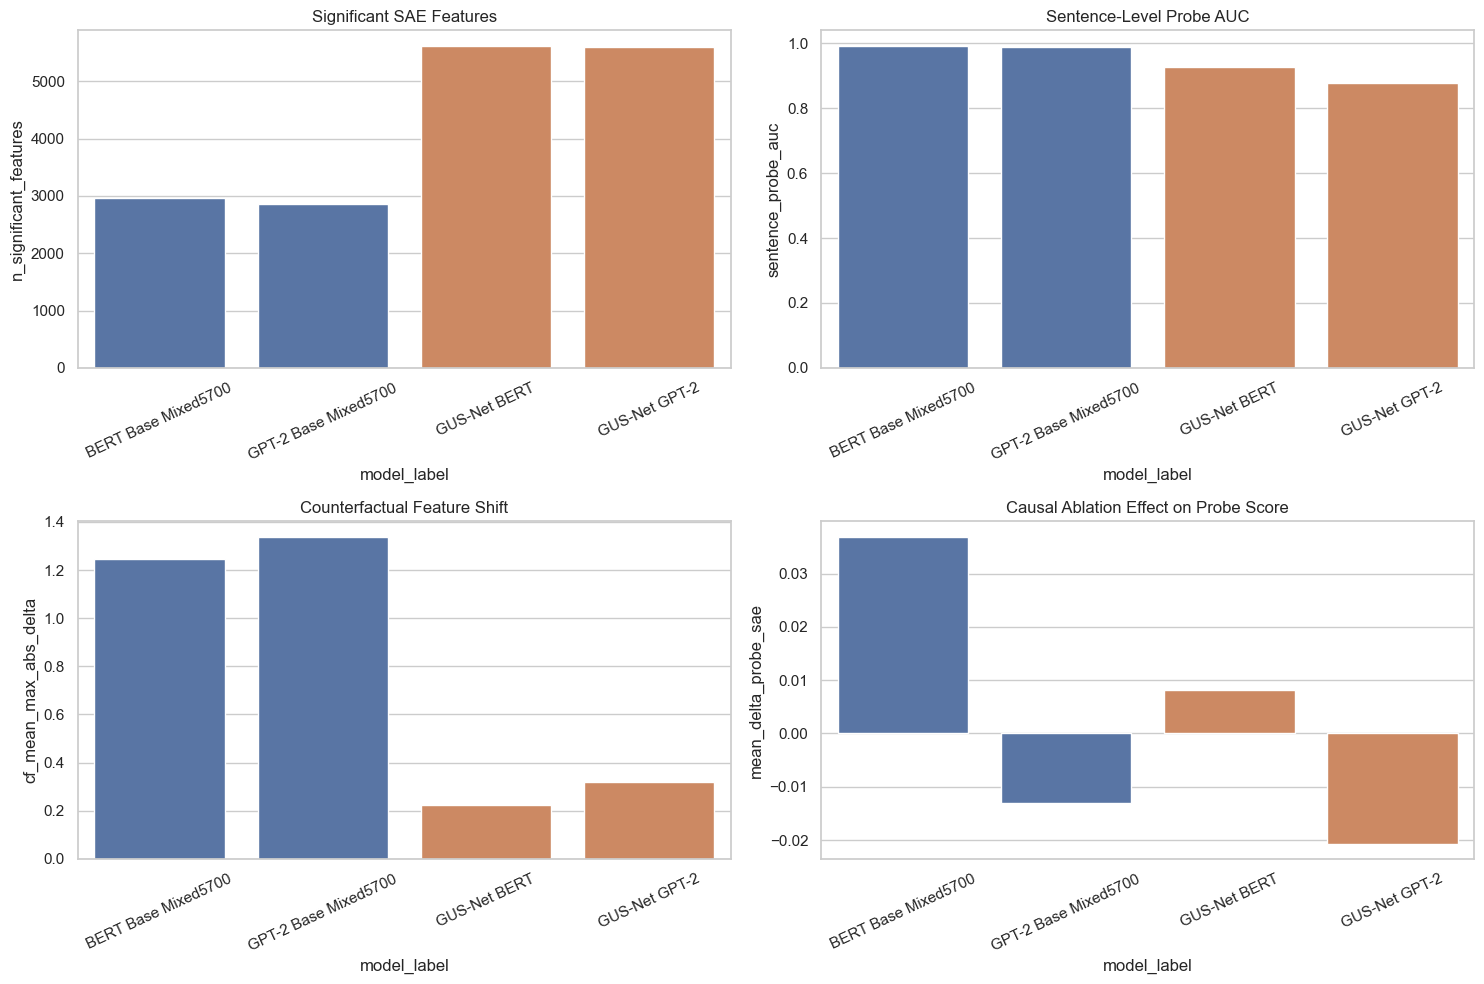

In [75]:
# Create an overview figure comparing key metrics across models, including significant features, probe AUC, counterfactual shift, and causal effect

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_df = comparison_df.copy()

sns.barplot(data=plot_df, x='model_label', y='n_significant_features', hue='analysis_group', ax=axes[0, 0])
axes[0, 0].set_title('Significant SAE Features')
axes[0, 0].tick_params(axis='x', rotation=25)

sns.barplot(data=plot_df, x='model_label', y='sentence_probe_auc', hue='analysis_group', ax=axes[0, 1])
axes[0, 1].set_title('Sentence-Level Probe AUC')
axes[0, 1].tick_params(axis='x', rotation=25)

sns.barplot(data=plot_df, x='model_label', y='cf_mean_max_abs_delta', hue='analysis_group', ax=axes[1, 0])
axes[1, 0].set_title('Counterfactual Feature Shift')
axes[1, 0].tick_params(axis='x', rotation=25)

sns.barplot(data=plot_df, x='model_label', y='mean_delta_probe_sae', hue='analysis_group', ax=axes[1, 1])
axes[1, 1].set_title('Causal Ablation Effect on Probe Score')
axes[1, 1].tick_params(axis='x', rotation=25)

for ax in axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    if handles and ax.legend_ is not None:
        ax.legend_.remove()

plt.tight_layout()
plt.show()

In [76]:
# Build a family-level comparison table contrasting mixed-5700 and GUS-Net results for BERT and GPT-2

family_rows = []
for family in ['bert', 'gpt2']:
    mixed_row = comparison_df[(comparison_df['family'] == family) & (comparison_df['analysis_group'] == 'mixed5700')]
    gus_row = comparison_df[(comparison_df['family'] == family) & (comparison_df['analysis_group'] == 'gusnet')]
    if len(mixed_row) == 1 and len(gus_row) == 1:
        mixed_row = mixed_row.iloc[0]
        gus_row = gus_row.iloc[0]
        family_rows.append({
            'family': family,
            'mixed_model': mixed_row['model_label'],
            'gus_model': gus_row['model_label'],
            'delta_significant_features': gus_row['n_significant_features'] - mixed_row['n_significant_features'],
            'delta_sentence_probe_auc': gus_row['sentence_probe_auc'] - mixed_row['sentence_probe_auc'],
            'delta_cf_shift': gus_row['cf_mean_max_abs_delta'] - mixed_row['cf_mean_max_abs_delta'],
            'delta_probe_ablation_effect': gus_row['mean_delta_probe_sae'] - mixed_row['mean_delta_probe_sae'],
            'delta_native_ablation_effect': gus_row['mean_delta_native_sae'],
        })
family_comparison_df = pd.DataFrame(family_rows)
family_comparison_df.to_csv(OUT_DIR / 'family_level_comparison.csv', index=False)
family_comparison_df

,family,mixed_model,gus_model,delta_significant_features,delta_sentence_probe_auc,delta_cf_shift,delta_probe_ablation_effect,delta_native_ablation_effect
0,bert,BERT Base Mixed5700,GUS-Net BERT,2645,-0.062840,-1.022830,-0.028795,0.001649
1,gpt2,GPT-2 Base Mixed5700,GUS-Net GPT-2,2745,-0.113356,-1.018121,-0.007555,-0.016107


## Full Layer Sweep

Because thesis claims about representation depth need stronger support than a single-layer probe,
the next cells perform an SAE sweep across **all transformer layers** for each model.

This is the section you should rely on if you want to argue where bias-related sparse structure is most concentrated.

In [77]:
# Run a full SAE layer sweep across all transformer layers for all models and save the layer-wise summary table

def run_full_layer_sweep_mixed(spec: dict, train_df: pd.DataFrame, test_df: pd.DataFrame):
    bundle = load_mixed_model_bundle(spec)
    rows = []
    train_subset = train_df.head(min(LAYER_SWEEP_SENTENCES, len(train_df))).reset_index(drop=True)
    test_subset = test_df.head(min(LAYER_SWEEP_SENTENCES, len(test_df))).reset_index(drop=True)
    for layer in LAYER_SWEEP_LAYERS:
        train_acts, train_meta = extract_sentence_activations(train_subset, bundle, layer, f"Sweep train L{layer} — {spec['label']}")
        test_acts, test_meta = extract_sentence_activations(test_subset, bundle, layer, f"Sweep test L{layer} — {spec['label']}")
        train_norm, test_norm, _, _ = normalize_train_test(train_acts.float(), test_acts.float())
        old_epochs = SAE_EPOCHS
        globals()['SAE_EPOCHS'] = LAYER_SWEEP_EPOCHS
        artifacts = train_sae(train_norm)
        globals()['SAE_EPOCHS'] = old_epochs
        train_feats = encode_with_sae(artifacts, train_norm)
        test_feats = encode_with_sae(artifacts, test_norm)
        feature_df, _ = analyse_features_binary(train_feats, train_meta['has_bias'].to_numpy(), test_feats, test_meta['has_bias'].to_numpy())
        _, sent_metrics = fit_probe(train_feats, train_meta['has_bias'].to_numpy(), test_feats, test_meta['has_bias'].to_numpy(), 'sentence_probe')
        rows.append({
            'model_label': spec['label'],
            'analysis_group': 'mixed5700',
            'layer': layer,
            'n_significant_features': int(feature_df['significant'].sum()),
            'max_abs_diff': float(feature_df['abs_diff'].max()),
            'mean_activation_freq': float(feature_df['activation_freq'].mean()),
            'sentence_probe_auc': float(sent_metrics['sentence_probe_auc']),
            'best_val_loss': float(pd.DataFrame(artifacts.history)['val_loss'].min()),
            'best_val_l0': float(pd.DataFrame(artifacts.history).loc[pd.DataFrame(artifacts.history)['val_loss'].idxmin(), 'val_l0']),
        })
        cleanup_cuda()
    return pd.DataFrame(rows)

def run_full_layer_sweep_gus(spec: dict, train_df: pd.DataFrame, test_df: pd.DataFrame):
    bundle = load_gus_bundle(spec)
    rows = []
    train_subset = train_df.head(min(LAYER_SWEEP_SENTENCES, len(train_df))).reset_index(drop=True)
    test_subset = test_df.head(min(LAYER_SWEEP_SENTENCES, len(test_df))).reset_index(drop=True)
    for layer in LAYER_SWEEP_LAYERS:
        train_acts, train_meta = extract_token_activations_gus(train_subset, bundle, layer, f"Sweep train L{layer} — {spec['label']}")
        test_acts, test_meta = extract_token_activations_gus(test_subset, bundle, layer, f"Sweep test L{layer} — {spec['label']}")
        train_norm, test_norm, _, _ = normalize_train_test(train_acts.float(), test_acts.float())
        old_epochs = SAE_EPOCHS
        globals()['SAE_EPOCHS'] = LAYER_SWEEP_EPOCHS
        artifacts = train_sae(train_norm)
        globals()['SAE_EPOCHS'] = old_epochs
        train_feats = encode_with_sae(artifacts, train_norm)
        test_feats = encode_with_sae(artifacts, test_norm)
        feature_df, _ = analyse_features_binary(train_feats, train_meta['bias_token'].to_numpy(), test_feats, test_meta['bias_token'].to_numpy())
        _, token_metrics = fit_probe(train_feats, train_meta['bias_token'].to_numpy(), test_feats, test_meta['bias_token'].to_numpy(), 'token_probe')
        rows.append({
            'model_label': spec['label'],
            'analysis_group': 'gusnet',
            'layer': layer,
            'n_significant_features': int(feature_df['significant'].sum()),
            'max_abs_diff': float(feature_df['abs_diff'].max()),
            'mean_activation_freq': float(feature_df['activation_freq'].mean()),
            'token_probe_auc': float(token_metrics['token_probe_auc']),
            'best_val_loss': float(pd.DataFrame(artifacts.history)['val_loss'].min()),
            'best_val_l0': float(pd.DataFrame(artifacts.history).loc[pd.DataFrame(artifacts.history)['val_loss'].idxmin(), 'val_l0']),
        })
        cleanup_cuda()
    return pd.DataFrame(rows)

run_layer_sweep_now = True
layer_sweep_frames = []
if run_layer_sweep_now:
    for spec in MIXED_MODELS:
        layer_sweep_frames.append(run_full_layer_sweep_mixed(spec, mixed_train_df, mixed_test_df))
    for spec in GUS_MODELS:
        layer_sweep_frames.append(run_full_layer_sweep_gus(spec, gus_train_df, gus_test_df))

layer_sweep_df = pd.concat(layer_sweep_frames, ignore_index=True) if layer_sweep_frames else pd.DataFrame()
layer_sweep_df.to_csv(OUT_DIR / 'layer_sweep_summary.csv', index=False)
layer_sweep_df.head()

c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model tha

Sweep train L0 — BERT Base Mixed5700:   0%|          | 0/180 [00:00<?, ?it/s]

Sweep test L0 — BERT Base Mixed5700:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 01 | train_loss=8.7189 | val_loss=7.9299 | val_l0=3081.1
Epoch 02 | train_loss=6.3303 | val_loss=7.1644 | val_l0=3083.9
Epoch 03 | train_loss=5.2033 | val_loss=6.9410 | val_l0=3083.3
Epoch 04 | train_loss=4.5949 | val_loss=6.8350 | val_l0=3084.9
Epoch 05 | train_loss=4.1331 | val_loss=6.6934 | val_l0=3088.9
Epoch 06 | train_loss=3.6821 | val_loss=6.5020 | val_l0=3090.4
Epoch 07 | train_loss=3.2259 | val_loss=6.2953 | val_l0=3091.0
Epoch 08 | train_loss=2.7916 | val_loss=6.1081 | val_l0=3091.2
Epoch 09 | train_loss=2.4069 | val_loss=5.9552 | val_l0=3091.7
Epoch 10 | train_loss=2.0839 | val_loss=5.8347 | val_l0=3093.1
Epoch 11 | train_loss=1.8193 | val_loss=5.7373 | val_l0=3095.7
Epoch 12 | train_loss=1.6021 | val_loss=5.6541 | val_l0=3097.9
Epoch 13 | train_loss=1.4209 | val_loss=5.5797 | val_l0=3099.6
Epoch 14 | train_loss=1.2660 | val_loss=5.5116 | val_l0=3100.7
Epoch 15 | train_loss=1.1307 | val_loss=5.4488 | val_l0=3101.2
Epoch 16 | train_loss=1.0103 | val_loss=5.3919 | val_l0

Feature tests:   0%|          | 0/6144 [00:00<?, ?it/s]

...

Sweep train L11 — GUS-Net GPT-2:   0%|          | 0/180 [00:00<?, ?it/s]

Sweep test L11 — GUS-Net GPT-2:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 01 | train_loss=4.3853 | val_loss=2.9787 | val_l0=3065.0
Epoch 02 | train_loss=2.4450 | val_loss=2.1869 | val_l0=3059.6
Epoch 03 | train_loss=1.7976 | val_loss=1.7736 | val_l0=3049.7
Epoch 04 | train_loss=1.4350 | val_loss=1.5360 | val_l0=3041.3
Epoch 05 | train_loss=1.1981 | val_loss=1.3783 | val_l0=3034.7
Epoch 06 | train_loss=1.0382 | val_loss=1.2641 | val_l0=3028.4
Epoch 07 | train_loss=0.9156 | val_loss=1.1804 | val_l0=3022.5
Epoch 08 | train_loss=0.8164 | val_loss=1.1095 | val_l0=3016.6
Epoch 09 | train_loss=0.7372 | val_loss=1.0550 | val_l0=3011.5
Epoch 10 | train_loss=0.6693 | val_loss=1.0036 | val_l0=3006.7
Epoch 11 | train_loss=0.6144 | val_loss=0.9612 | val_l0=3002.5
Epoch 12 | train_loss=0.5646 | val_loss=0.9264 | val_l0=2999.3
Epoch 13 | train_loss=0.5265 | val_loss=0.8976 | val_l0=2994.7
Epoch 14 | train_loss=0.4898 | val_loss=0.8681 | val_l0=2991.6
Epoch 15 | train_loss=0.4565 | val_loss=0.8444 | val_l0=2989.0
Epoch 16 | train_loss=0.4333 | val_loss=0.8247 | val_l0

Feature tests:   0%|          | 0/6144 [00:00<?, ?it/s]

,model_label,analysis_group,layer,n_significant_features,max_abs_diff,mean_activation_freq,sentence_probe_auc,best_val_loss,best_val_l0,token_probe_auc
0,BERT Base Mixed5700,mixed5700,0,1773,1.064133,0.498050,0.950689,4.922840,3132.444580,NaN
1,BERT Base Mixed5700,mixed5700,1,1841,1.136975,0.498227,0.958018,4.280947,3147.055664,NaN
2,BERT Base Mixed5700,mixed5700,2,1889,1.282349,0.498525,0.964228,4.405094,3133.666748,NaN
3,BERT Base Mixed5700,mixed5700,3,2111,1.409684,0.499065,0.965346,4.011781,3125.555664,NaN
4,BERT Base Mixed5700,mixed5700,4,2099,1.295063,0.497672,0.969196,4.129136,3126.777832,NaN


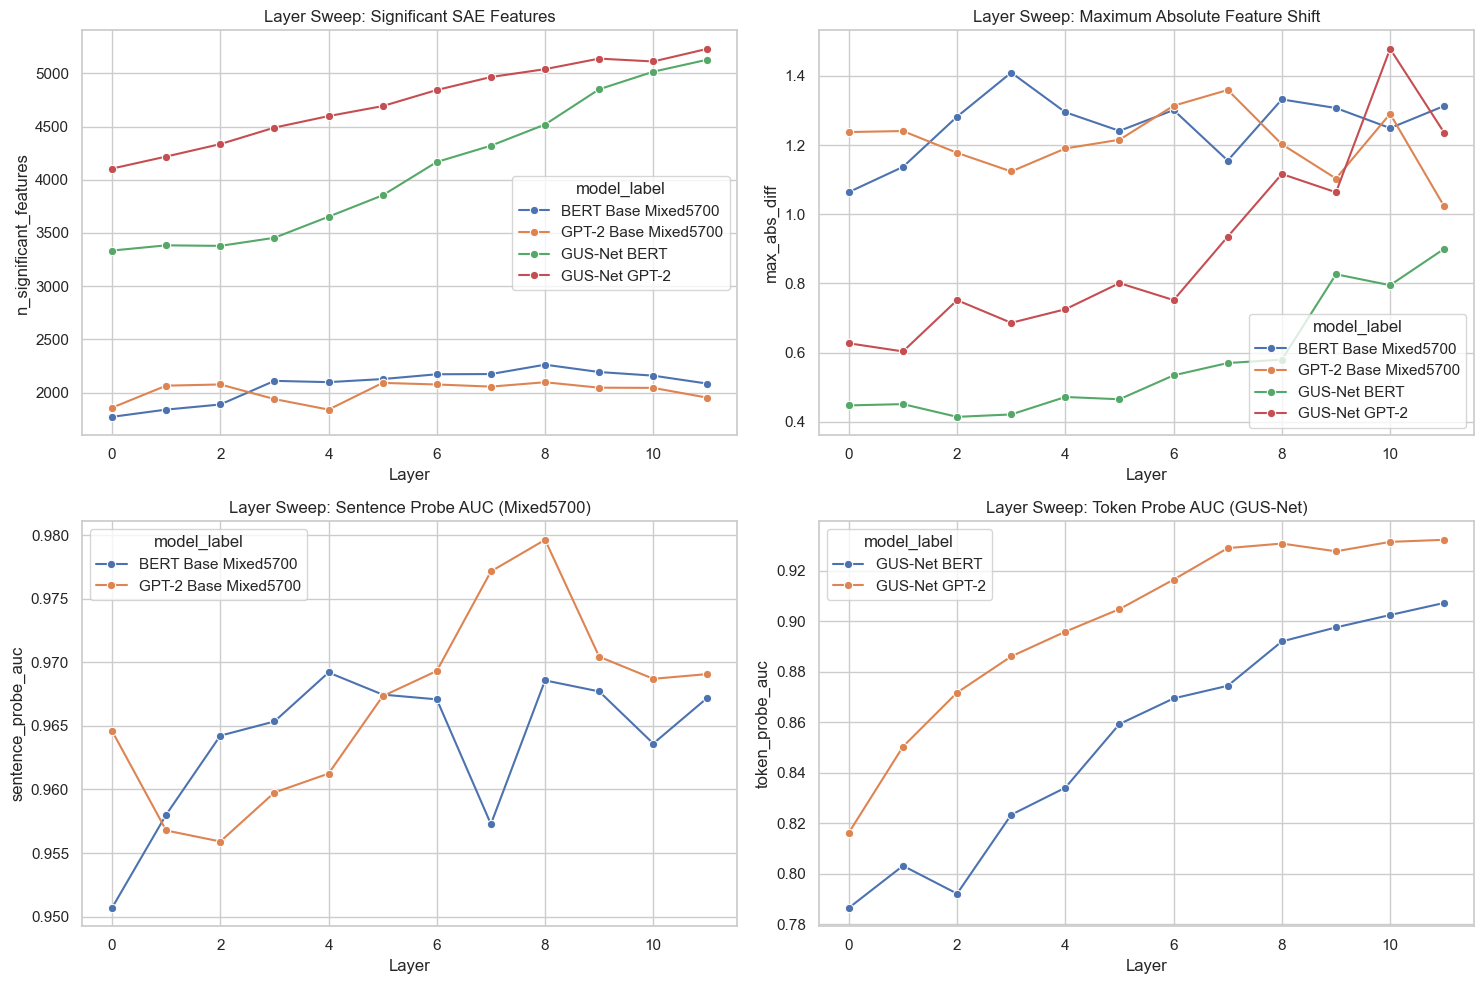

,model_label,analysis_group,layer,n_significant_features,max_abs_diff,mean_activation_freq,sentence_probe_auc,best_val_loss,best_val_l0,token_probe_auc
0,BERT Base Mixed5700,mixed5700,0,1773,1.064133,0.498050,0.950689,4.922840,3132.444580,NaN
1,BERT Base Mixed5700,mixed5700,1,1841,1.136975,0.498227,0.958018,4.280947,3147.055664,NaN
2,BERT Base Mixed5700,mixed5700,2,1889,1.282349,0.498525,0.964228,4.405094,3133.666748,NaN
3,BERT Base Mixed5700,mixed5700,3,2111,1.409684,0.499065,0.965346,4.011781,3125.555664,NaN
4,BERT Base Mixed5700,mixed5700,4,2099,1.295063,0.497672,0.969196,4.129136,3126.777832,NaN
5,BERT Base Mixed5700,mixed5700,5,2128,1.241114,0.498844,0.967457,3.683340,3131.333252,NaN
6,BERT Base Mixed5700,mixed5700,6,2173,1.301483,0.497852,0.967085,4.127813,3124.666748,NaN
7,BERT Base Mixed5700,mixed5700,7,2175,1.155332,0.498794,0.957272,3.407255,3144.500000,NaN
8,BERT Base Mixed5700,mixed5700,8,2263,1.332186,0.498409,0.968575,3.992350,3130.888916,NaN
9,BERT Base Mixed5700,mixed5700,9,2194,1.307196,0.499009,0.967706,3.986397,3117.111084,NaN


In [78]:
# Visualize the full layer sweep and highlight where sparse bias structure is strongest in each model family

if len(layer_sweep_df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    sns.lineplot(data=layer_sweep_df, x='layer', y='n_significant_features', hue='model_label', marker='o', ax=axes[0, 0])
    axes[0, 0].set_title('Layer Sweep: Significant SAE Features')

    sns.lineplot(data=layer_sweep_df, x='layer', y='max_abs_diff', hue='model_label', marker='o', ax=axes[0, 1])
    axes[0, 1].set_title('Layer Sweep: Maximum Absolute Feature Shift')

    mixed_layers = layer_sweep_df[layer_sweep_df['analysis_group'] == 'mixed5700']
    if len(mixed_layers):
        sns.lineplot(data=mixed_layers, x='layer', y='sentence_probe_auc', hue='model_label', marker='o', ax=axes[1, 0])
        axes[1, 0].set_title('Layer Sweep: Sentence Probe AUC (Mixed5700)')
    else:
        axes[1, 0].set_axis_off()

    gus_layers = layer_sweep_df[layer_sweep_df['analysis_group'] == 'gusnet']
    if len(gus_layers):
        sns.lineplot(data=gus_layers, x='layer', y='token_probe_auc', hue='model_label', marker='o', ax=axes[1, 1])
        axes[1, 1].set_title('Layer Sweep: Token Probe AUC (GUS-Net)')
    else:
        axes[1, 1].set_axis_off()

for ax in axes.flat:
    if ax.has_data():
        ax.set_xlabel('Layer')

plt.tight_layout()
plt.show()

layer_sweep_df


In [79]:
# Load all per-model result tables from disk so later figures can reuse saved outputs instead of recomputing them

def model_slug(label: str) -> str:
    return label.lower().replace(' ', '_').replace('-', '_')

def load_result_table(model_label: str, filename: str) -> pd.DataFrame:
    path = OUT_DIR / model_slug(model_label) / filename
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

model_tables = {}
for model_label in comparison_df['model_label']:
    model_tables[model_label] = {
        'history': load_result_table(model_label, 'sae_training_history.csv'),
        'features': load_result_table(model_label, 'feature_statistics.csv'),
        'top_features': load_result_table(model_label, 'top_features.csv'),
        'examples': load_result_table(model_label, 'top_feature_examples.csv'),
        'counterfactual': load_result_table(model_label, 'counterfactual_pairs.csv'),
        'intervention': load_result_table(model_label, 'intervention_results.csv'),
    }

pd.DataFrame({
    model_label: {k: int(len(v)) for k, v in tables.items()}
    for model_label, tables in model_tables.items()
}).T

,history,features,top_features,examples,counterfactual,intervention
BERT Base Mixed5700,75,6144,15,75,39,50
GPT-2 Base Mixed5700,75,6144,15,75,39,50
GUS-Net BERT,75,6144,15,75,52,50
GUS-Net GPT-2,75,6144,15,75,52,50


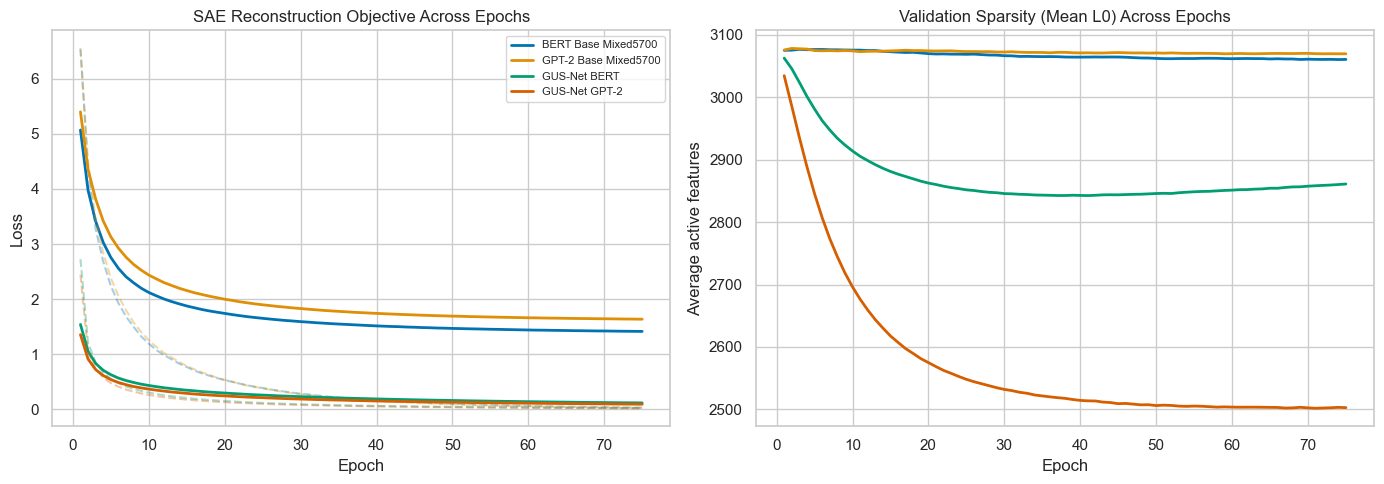

In [80]:
# Plot SAE optimization diagnostics, including reconstruction loss and validation sparsity across training epochs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('colorblind', n_colors=len(comparison_df))

for color, model_label in zip(palette, comparison_df['model_label']):
    history = model_tables[model_label]['history']
    if len(history) == 0:
        continue
    axes[0].plot(history['epoch'], history['train_loss'], color=color, alpha=0.35, linestyle='--')
    axes[0].plot(history['epoch'], history['val_loss'], color=color, linewidth=2, label=model_label)
    axes[1].plot(history['epoch'], history['val_l0'], color=color, linewidth=2, label=model_label)

axes[0].set_title('SAE Reconstruction Objective Across Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Validation Sparsity (Mean L0) Across Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Average active features')

plt.tight_layout()
plt.show()

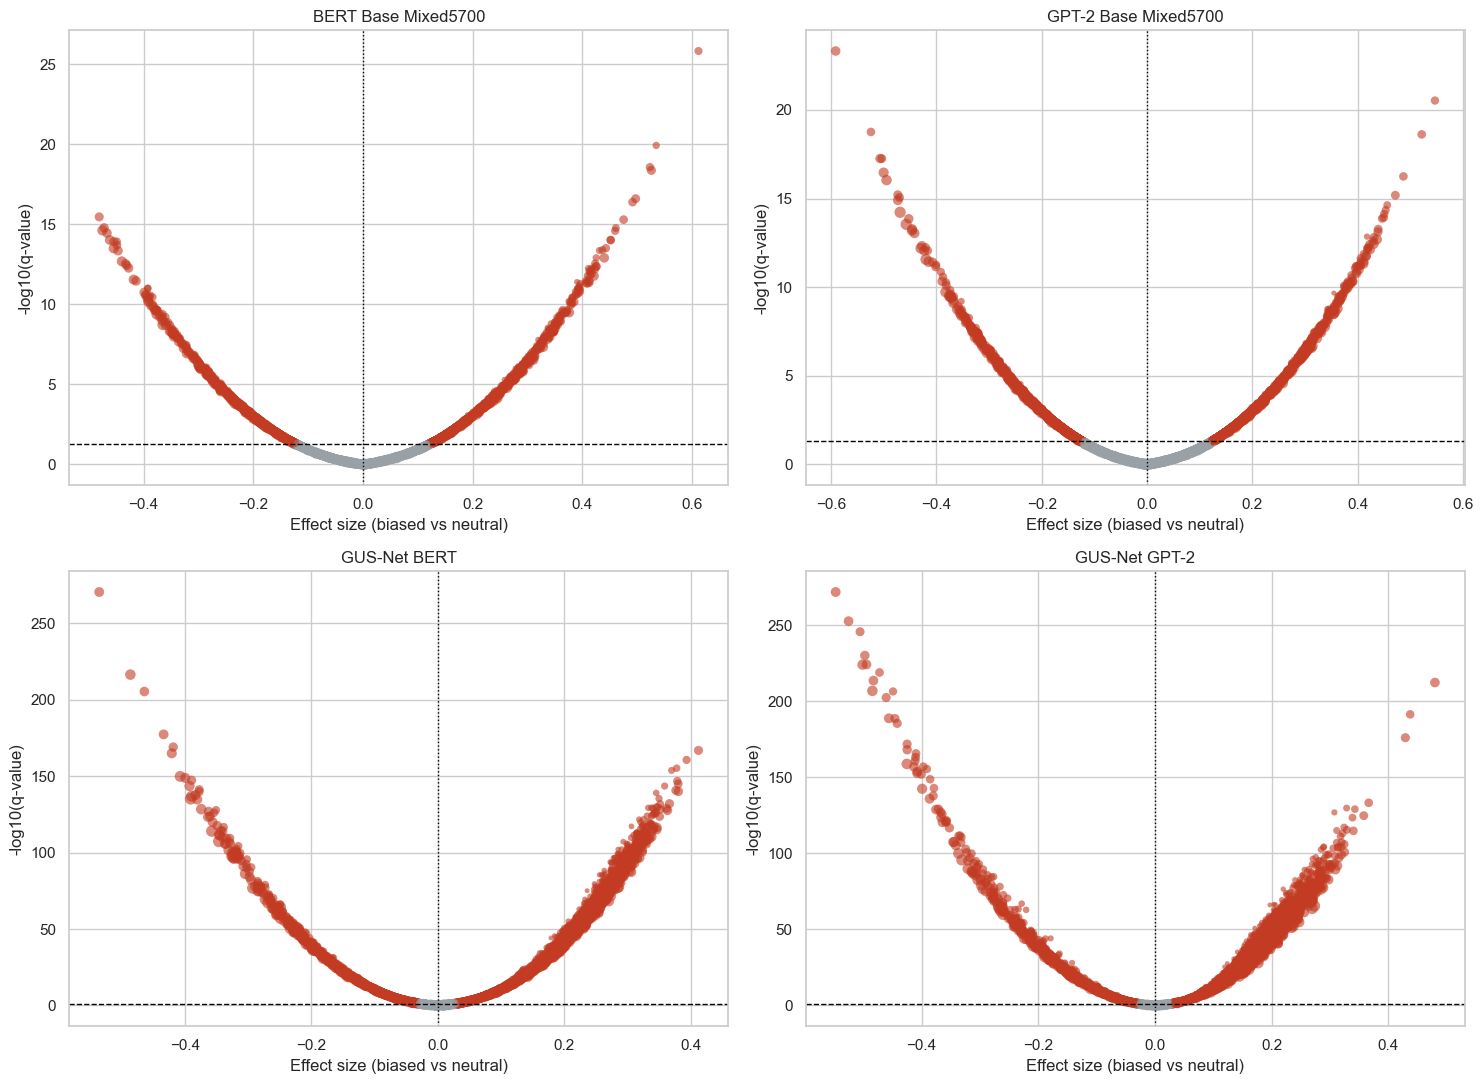

In [81]:
# Plot feature-level significance landscapes to show how effect size and statistical significance vary across learned SAE features

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()
for ax, model_label in zip(axes, comparison_df['model_label']):
    feat_df = model_tables[model_label]['features'].copy()
    if len(feat_df) == 0:
        ax.set_axis_off()
        continue
    feat_df['neglog10_q'] = -np.log10(feat_df['q_value'].clip(lower=1e-300))
    sns.scatterplot(
        data=feat_df.sample(n=min(4000, len(feat_df)), random_state=42),
        x='effect_size',
        y='neglog10_q',
        hue='significant',
        size='activation_freq',
        sizes=(12, 70),
        palette={False: '#9aa1a6', True: '#c23b22'},
        alpha=0.6,
        linewidth=0,
        legend=False,
        ax=ax,
    )
    ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=1)
    ax.axvline(0.0, color='black', linestyle=':', linewidth=1)
    ax.set_title(model_label)
    ax.set_xlabel('Effect size (biased vs neutral)')
    ax.set_ylabel('-log10(q-value)')

plt.tight_layout()
plt.show()

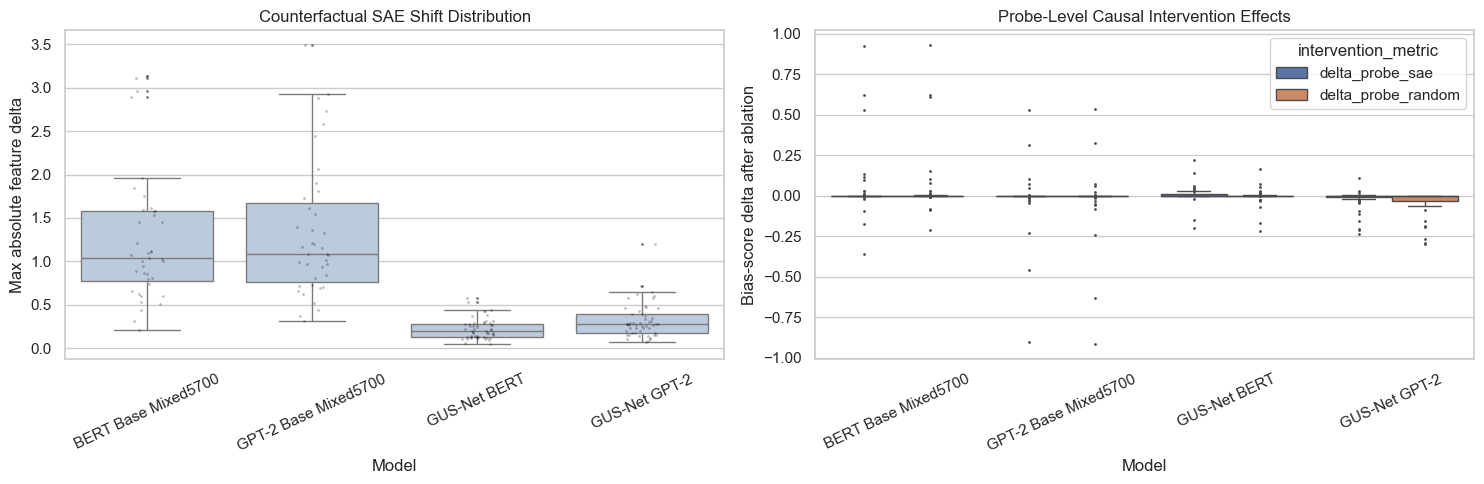

,model_label,probe_delta_sae_mean,probe_delta_random_mean,wilcoxon_stat,wilcoxon_p
0,BERT Base Mixed5700,0.036908,0.043828,349.0,4.757047e-03
1,GPT-2 Base Mixed5700,-0.013079,-0.020337,244.0,7.861201e-05
2,GUS-Net BERT,0.008113,-0.003517,35.0,7.656098e-12
3,GUS-Net GPT-2,-0.020634,-0.037256,0.0,1.776357e-15


In [82]:
# Compare counterfactual shifts and causal intervention effects, and run a Wilcoxon test against random feature ablations

cf_plot_rows = []
int_plot_rows = []
int_test_rows = []

for model_label, tables in model_tables.items():
    cf_df = tables['counterfactual'].copy()
    if len(cf_df):
        cf_df['model_label'] = model_label
        cf_plot_rows.append(cf_df)

    int_df = tables['intervention'].copy()
    if len(int_df):
        int_df['model_label'] = model_label
        melted = int_df.melt(
            id_vars=['model_label'],
            value_vars=[c for c in ['delta_probe_sae', 'delta_probe_random', 'delta_native_sae', 'delta_native_random'] if c in int_df.columns],
            var_name='intervention_metric',
            value_name='delta',
        )
        int_plot_rows.append(melted)

        if {'delta_probe_sae', 'delta_probe_random'}.issubset(int_df.columns):
            try:
                stat, p_val = stats.wilcoxon(int_df['delta_probe_sae'], int_df['delta_probe_random'])
            except ValueError:
                stat, p_val = np.nan, np.nan
            int_test_rows.append({
                'model_label': model_label,
                'probe_delta_sae_mean': float(int_df['delta_probe_sae'].mean()),
                'probe_delta_random_mean': float(int_df['delta_probe_random'].mean()),
                'wilcoxon_stat': stat,
                'wilcoxon_p': p_val,
            })

cf_plot_df = pd.concat(cf_plot_rows, ignore_index=True) if cf_plot_rows else pd.DataFrame()
int_plot_df = pd.concat(int_plot_rows, ignore_index=True) if int_plot_rows else pd.DataFrame()
intervention_test_df = pd.DataFrame(int_test_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
if len(cf_plot_df):
    sns.boxplot(data=cf_plot_df, x='model_label', y='max_abs_delta', ax=axes[0], color='#b7c9e2', fliersize=1)
    sns.stripplot(data=cf_plot_df, x='model_label', y='max_abs_delta', ax=axes[0], color='black', alpha=0.25, size=2)
    axes[0].set_title('Counterfactual SAE Shift Distribution')
    axes[0].set_xlabel('Model')
    axes[0].set_ylabel('Max absolute feature delta')
    axes[0].tick_params(axis='x', rotation=25)
else:
    axes[0].set_axis_off()

if len(int_plot_df):
    probe_only = int_plot_df[int_plot_df['intervention_metric'].isin(['delta_probe_sae', 'delta_probe_random'])].copy()
    sns.boxplot(data=probe_only, x='model_label', y='delta', hue='intervention_metric', ax=axes[1], fliersize=1)
    axes[1].set_title('Probe-Level Causal Intervention Effects')
    axes[1].set_xlabel('Model')
    axes[1].set_ylabel('Bias-score delta after ablation')
    axes[1].tick_params(axis='x', rotation=25)
else:
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()
intervention_test_df

## Layer and Head Alignment With Attention Atlas

The thesis is not only about hidden-state SAE features in isolation.
It is also about how these internal sparse features relate to the attention-centric analysis already present in Attention Atlas.
The next cells connect the SAE results to your existing head-specialization and head-importance pipeline.

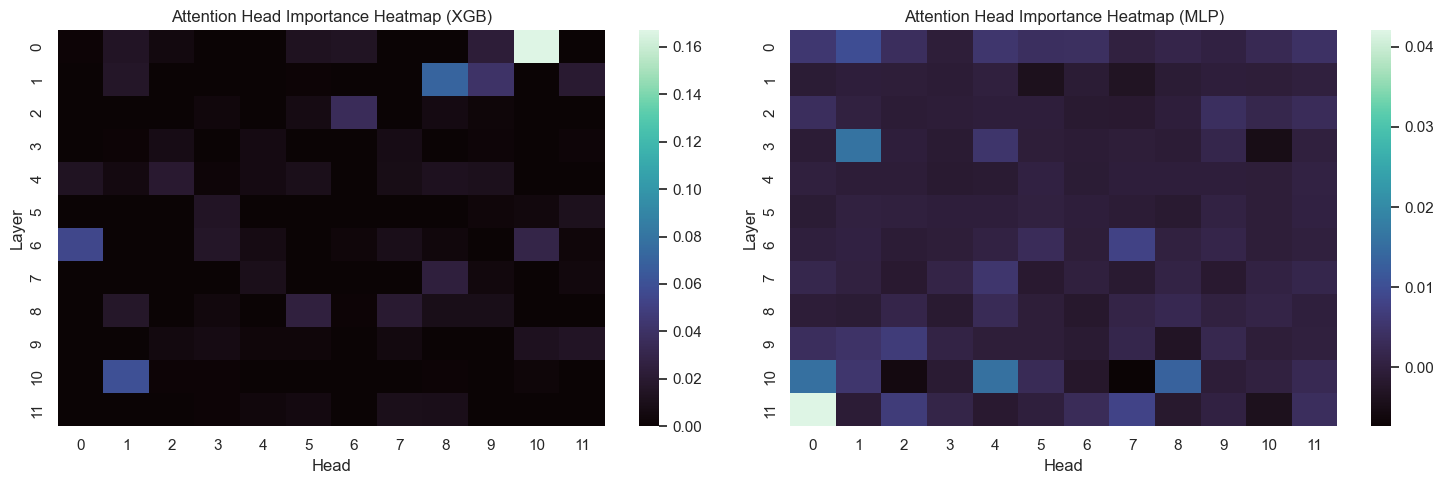

In [83]:
# What this cell does: Load the existing attention-head importance files from Attention Atlas and visualize them as head-by-layer heatmaps

xgb_head_df = pd.read_csv(ROOT / 'attention_app' / 'bias' / 'head_importance_xgbclassifier.csv')
mlp_head_df = pd.read_csv(ROOT / 'attention_app' / 'bias' / 'head_importance_mlpclassifier.csv')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
xgb_pivot = xgb_head_df.pivot(index='Layer', columns='Head', values='Total_Importance').fillna(0.0)
mlp_pivot = mlp_head_df.pivot(index='Layer', columns='Head', values='Total_Importance').fillna(0.0)
sns.heatmap(xgb_pivot, cmap='mako', ax=axes[0])
axes[0].set_title('Attention Head Importance Heatmap (XGB)')
axes[0].set_xlabel('Head')
axes[0].set_ylabel('Layer')
sns.heatmap(mlp_pivot, cmap='mako', ax=axes[1])
axes[1].set_title('Attention Head Importance Heatmap (MLP)')
axes[1].set_xlabel('Head')
axes[1].set_ylabel('Layer')
plt.tight_layout()
plt.show()

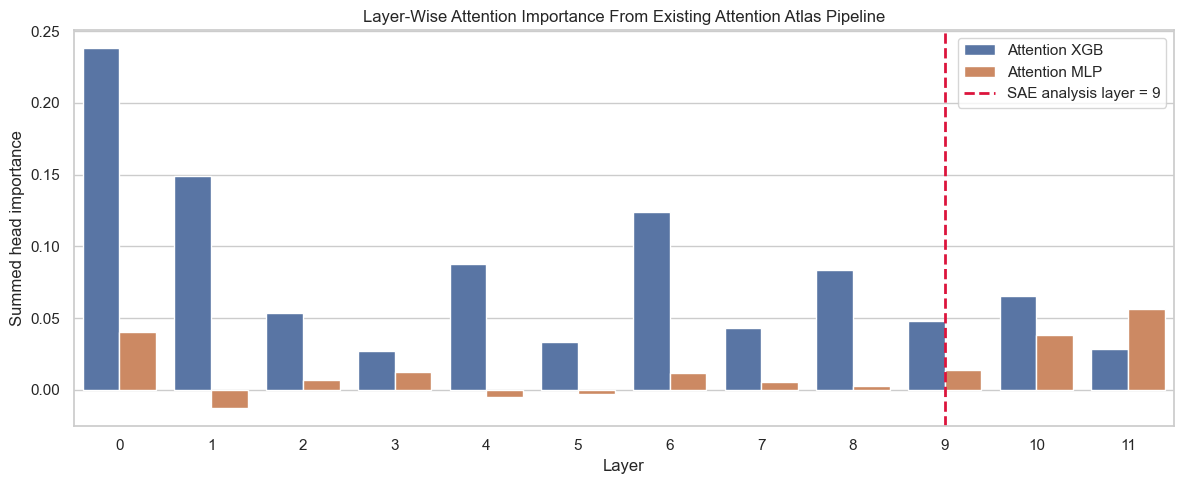

,Layer,xgb_total_importance,mlp_total_importance,xgb_rank,mlp_rank,is_sae_layer
0,0,0.237970,0.040582,1.0,2.0,False
1,1,0.148973,-0.012727,2.0,12.0,False
2,2,0.053910,0.006982,7.0,7.0,False
3,3,0.026940,0.012655,12.0,5.0,False
4,4,0.087672,-0.005091,4.0,11.0,False
5,5,0.033383,-0.002909,10.0,10.0,False
6,6,0.124324,0.011709,3.0,6.0,False
7,7,0.042848,0.005382,9.0,8.0,False
8,8,0.083589,0.003055,5.0,9.0,False
9,9,0.047849,0.013964,8.0,4.0,True


In [84]:
# Aggregate attention-head importance by layer and compare the SAE analysis depth with the existing attention-based importance profile

xgb_layer = xgb_head_df.groupby('Layer', as_index=False)['Total_Importance'].sum()
xgb_layer['source'] = 'Attention XGB'
mlp_layer = mlp_head_df.groupby('Layer', as_index=False)['Total_Importance'].sum()
mlp_layer['source'] = 'Attention MLP'
layer_importance_df = pd.concat([xgb_layer, mlp_layer], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=layer_importance_df, x='Layer', y='Total_Importance', hue='source', ax=ax)
ax.axvline(DEFAULT_LAYER_IDX, color='crimson', linestyle='--', linewidth=2, label=f'SAE analysis layer = {DEFAULT_LAYER_IDX}')
ax.set_title('Layer-Wise Attention Importance From Existing Attention Atlas Pipeline')
ax.set_ylabel('Summed head importance')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.show()

layer_rank_df = pd.DataFrame({
    'Layer': sorted(set(xgb_layer['Layer']).union(set(mlp_layer['Layer']))),
})
layer_rank_df = layer_rank_df.merge(xgb_layer[['Layer', 'Total_Importance']].rename(columns={'Total_Importance': 'xgb_total_importance'}), on='Layer', how='left')
layer_rank_df = layer_rank_df.merge(mlp_layer[['Layer', 'Total_Importance']].rename(columns={'Total_Importance': 'mlp_total_importance'}), on='Layer', how='left')
layer_rank_df['xgb_rank'] = layer_rank_df['xgb_total_importance'].rank(ascending=False, method='min')
layer_rank_df['mlp_rank'] = layer_rank_df['mlp_total_importance'].rank(ascending=False, method='min')
layer_rank_df['is_sae_layer'] = layer_rank_df['Layer'] == DEFAULT_LAYER_IDX
layer_rank_df.sort_values('Layer')

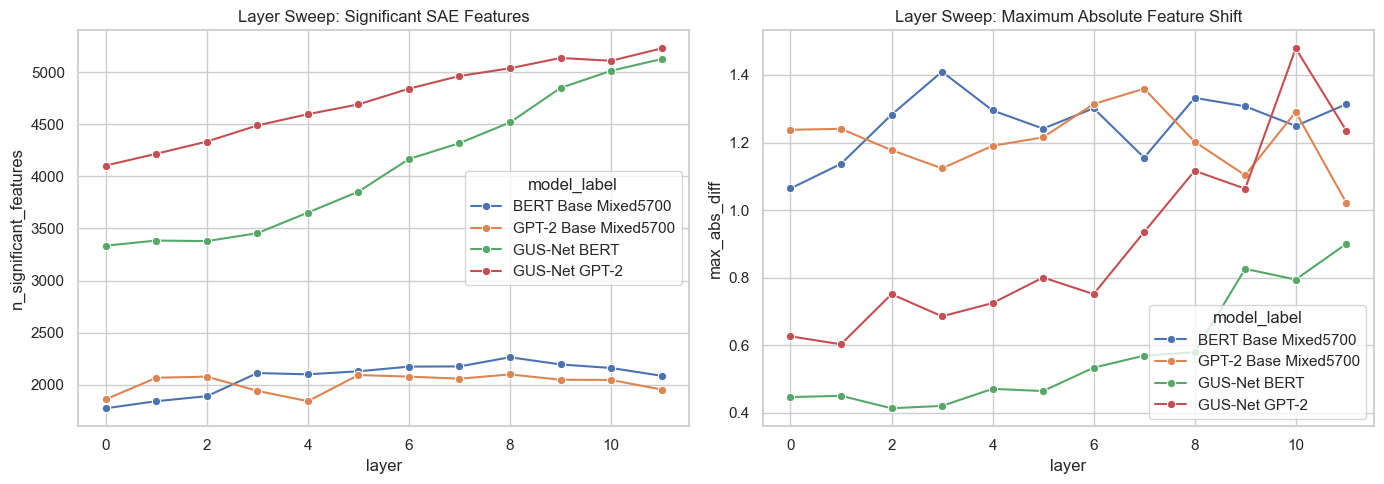

,model_label,analysis_group,layer,n_significant_features,max_abs_diff,mean_activation_freq,sentence_probe_auc,best_val_loss,best_val_l0,token_probe_auc
0,BERT Base Mixed5700,mixed5700,0,1773,1.064133,0.498050,0.950689,4.922840,3132.444580,NaN
1,BERT Base Mixed5700,mixed5700,1,1841,1.136975,0.498227,0.958018,4.280947,3147.055664,NaN
2,BERT Base Mixed5700,mixed5700,2,1889,1.282349,0.498525,0.964228,4.405094,3133.666748,NaN
3,BERT Base Mixed5700,mixed5700,3,2111,1.409684,0.499065,0.965346,4.011781,3125.555664,NaN
4,BERT Base Mixed5700,mixed5700,4,2099,1.295063,0.497672,0.969196,4.129136,3126.777832,NaN
5,BERT Base Mixed5700,mixed5700,5,2128,1.241114,0.498844,0.967457,3.683340,3131.333252,NaN
6,BERT Base Mixed5700,mixed5700,6,2173,1.301483,0.497852,0.967085,4.127813,3124.666748,NaN
7,BERT Base Mixed5700,mixed5700,7,2175,1.155332,0.498794,0.957272,3.407255,3144.500000,NaN
8,BERT Base Mixed5700,mixed5700,8,2263,1.332186,0.498409,0.968575,3.992350,3130.888916,NaN
9,BERT Base Mixed5700,mixed5700,9,2194,1.307196,0.499009,0.967706,3.986397,3117.111084,NaN


In [85]:
#  Reload the saved layer-sweep file and render publication-style layer-level plots directly from the stored results

layer_sweep_path = OUT_DIR / 'layer_sweep_summary.csv'
if layer_sweep_path.exists():
    layer_sweep_df = pd.read_csv(layer_sweep_path)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.lineplot(data=layer_sweep_df, x='layer', y='n_significant_features', hue='model_label', marker='o', ax=axes[0])
    axes[0].set_title('Layer Sweep: Significant SAE Features')
    sns.lineplot(data=layer_sweep_df, x='layer', y='max_abs_diff', hue='model_label', marker='o', ax=axes[1])
    axes[1].set_title('Layer Sweep: Maximum Absolute Feature Shift')
    plt.tight_layout()
    plt.show()
    display(layer_sweep_df)
else:
    print('No layer sweep file found yet. If you want stronger layer-level claims, set RUN_LAYER_SWEEP = True and rerun the notebook.')

## Conclusions and Framing



In [86]:
# Assemble a concise conclusion table that extracts the strongest model-level findings from the full experiment

conclusion_rows = []

best_sentence_model = comparison_df.sort_values('sentence_probe_auc', ascending=False).iloc[0]
most_sparse_model = comparison_df.sort_values('best_val_l0').iloc[0]
most_significant_model = comparison_df.sort_values('n_significant_features', ascending=False).iloc[0]

conclusion_rows.append({
    'claim': 'Best sentence-level separability',
    'evidence': f"{best_sentence_model['model_label']} reached sentence_probe_auc={best_sentence_model['sentence_probe_auc']:.3f}.",
    'interpretation': 'Sentence-level mixed5700 models remain extremely strong for coarse bias detection.'
})
conclusion_rows.append({
    'claim': 'Largest number of significant SAE features',
    'evidence': f"{most_significant_model['model_label']} produced {int(most_significant_model['n_significant_features'])} significant features.",
    'interpretation': 'Fine-tuned GUS-Net models expose a denser set of bias-associated sparse directions than the mixed5700 base models.'
})
conclusion_rows.append({
    'claim': 'Strongest sparsity pressure outcome',
    'evidence': f"{most_sparse_model['model_label']} had the lowest validation L0 ({most_sparse_model['best_val_l0']:.1f}).",
    'interpretation': 'This model reaches a more selective latent code under the same SAE design.'
})

thesis_conclusion_df = pd.DataFrame(conclusion_rows)
thesis_conclusion_df

,claim,evidence,interpretation
0,Best sentence-level separability,BERT Base Mixed5700 reached sentence_probe_auc...,Sentence-level mixed5700 models remain extreme...
1,Largest number of significant SAE features,GUS-Net BERT produced 5609 significant features.,Fine-tuned GUS-Net models expose a denser set ...
2,Strongest sparsity pressure outcome,GUS-Net GPT-2 had the lowest validation L0 (25...,This model reaches a more selective latent cod...


In [87]:
# What this cell does: Print thesis-oriented interpretation guidance describing how to position the SAE results in the dissertation.

print('Suggested thesis framing:')
print()
print('1. Mixed-5700 models show that bias is highly recoverable from sentence-level hidden representations.')
print('2. GUS-Net models show that fine-tuning for span-level bias detection increases the number of SAE features associated with bias.')
print('3. However, more significant SAE features do not automatically imply stronger sentence-level counterfactual sensitivity.')
print('4. The causal intervention results are mixed, so SAE evidence should be presented as complementary mechanistic evidence rather than definitive causal proof.')
print('5. The most defensible thesis claim is that SAE reveals an additional internal feature space that complements the attention-head analysis already provided by Attention Atlas.')
print()
print('How to integrate with your thesis chapters:')
print('- Chapter 3 / Methodology: introduce the SAE setup as a sparse latent probe over hidden states.')
print('- Chapter 4 / Validation: report feature statistics, probe separability, counterfactual shifts, and intervention results.')
print('- Chapter 4 / Attention comparison: compare SAE layer choices with the most important layers and heads from Attention Atlas.')
print('- Chapter 6 / Discussion: argue that attention and SAE capture complementary views of bias encoding: head-level routing vs latent representational structure.')

Suggested thesis framing:

1. Mixed-5700 models show that bias is highly recoverable from sentence-level hidden representations.
2. GUS-Net models show that fine-tuning for span-level bias detection increases the number of SAE features associated with bias.
3. However, more significant SAE features do not automatically imply stronger sentence-level counterfactual sensitivity.
4. The causal intervention results are mixed, so SAE evidence should be presented as complementary mechanistic evidence rather than definitive causal proof.
5. The most defensible thesis claim is that SAE reveals an additional internal feature space that complements the attention-head analysis already provided by Attention Atlas.

How to integrate with your thesis chapters:
- Chapter 3 / Methodology: introduce the SAE setup as a sparse latent probe over hidden states.
- Chapter 4 / Validation: report feature statistics, probe separability, counterfactual shifts, and intervention results.
- Chapter 4 / Attention co

## Thesis Interpretation Notes

This notebook now supports a stronger thesis narrative:
- the **mixed-5700 analysis** corresponds to sentence-level bias detection in the earlier BERT/GPT-2 pipeline;
- the **GUS-Net analysis** corresponds to span-level token supervision in `gus_dataset_clean.json`;
- the **attention heatmaps and layer plots** connect SAE findings back to the attention-centric contribution of Attention Atlas.

The strongest way to position this in the thesis is:
- attention analysis explains **which heads and layers are behaviorally important**;
- SAE analysis explains **which sparse latent features inside those representations are bias-associated**;
- together, they provide a more complete interpretability account than either method alone.

## Final Organized Conclusions

These final cells summarize the all-layer SAE sweep in a thesis-ready form.
They identify the best layers per model and state the strongest conclusions that can be defended rigorously from the current results.

In [88]:
# Summarize the best-performing layers for each model and save a compact thesis table.

import pandas as pd
layer_sweep_path = OUT_DIR / "layer_sweep_summary.csv"
layer_sweep_final_df = pd.read_csv(layer_sweep_path) if layer_sweep_path.exists() else layer_sweep_df.copy()
best_layer_rows = []
for model_label, sub_df in layer_sweep_final_df.groupby("model_label"):
    analysis_group = sub_df["analysis_group"].iloc[0]
    metric_col = "sentence_probe_auc" if analysis_group == "mixed5700" else "token_probe_auc"
    peak_row = sub_df.sort_values(metric_col, ascending=False).iloc[0]
    sig_row = sub_df.sort_values("n_significant_features", ascending=False).iloc[0]
    diff_row = sub_df.sort_values("max_abs_diff", ascending=False).iloc[0]
    best_layer_rows.append({
        "model_label": model_label,
        "analysis_group": analysis_group,
        "best_predictive_layer": int(peak_row["layer"]),
        "best_predictive_score": float(peak_row[metric_col]),
        "most_feature_rich_layer": int(sig_row["layer"]),
        "n_significant_features_peak": int(sig_row["n_significant_features"]),
        "largest_shift_layer": int(diff_row["layer"]),
        "largest_shift_value": float(diff_row["max_abs_diff"]),
    })
best_layers_df = pd.DataFrame(best_layer_rows)
best_layers_df.to_csv(OUT_DIR / "best_layers_per_model.csv", index=False)
best_layers_df


,model_label,analysis_group,best_predictive_layer,best_predictive_score,most_feature_rich_layer,n_significant_features_peak,largest_shift_layer,largest_shift_value
0,BERT Base Mixed5700,mixed5700,4,0.969196,8,2263,3,1.409684
1,GPT-2 Base Mixed5700,mixed5700,8,0.979630,8,2098,7,1.359485
2,GUS-Net BERT,gusnet,11,0.907187,11,5128,11,0.900131
3,GUS-Net GPT-2,gusnet,11,0.932168,11,5230,10,1.478534


In [90]:
# Print organized thesis-ready conclusions from the full layer sweep and the main SAE results

layer_sweep_path = OUT_DIR / "layer_sweep_summary.csv"
layer_sweep_final_df = pd.read_csv(layer_sweep_path) if layer_sweep_path.exists() else layer_sweep_df.copy()
group_peak_rows = []
for analysis_group, sub_df in layer_sweep_final_df.groupby("analysis_group"):
    metric_col = "sentence_probe_auc" if analysis_group == "mixed5700" else "token_probe_auc"
    avg_df = sub_df.groupby("layer", as_index=False).mean(numeric_only=True)
    peak = avg_df.sort_values(metric_col, ascending=False).iloc[0]
    group_peak_rows.append({
        "analysis_group": analysis_group,
        "peak_layer": int(peak["layer"]),
        "metric": metric_col,
        "value": float(peak[metric_col]),
    })
group_peak_df = pd.DataFrame(group_peak_rows)

for _, row in best_layers_df.iterrows():
    print(f"{row['model_label']}: best predictive layer = L{int(row['best_predictive_layer'])}, most feature-rich layer = L{int(row['most_feature_rich_layer'])}, largest shift layer = L{int(row['largest_shift_layer'])}.")
print()

mixed_peak = group_peak_df[group_peak_df["analysis_group"] == "mixed5700"].iloc[0]
gus_peak = group_peak_df[group_peak_df["analysis_group"] == "gusnet"].iloc[0]

print(f"Mixed-5700 group peak: layer L{int(mixed_peak['peak_layer'])} with {mixed_peak['metric']}={mixed_peak['value']:.4f}.")
print(f"GUS-Net group peak: layer L{int(gus_peak['peak_layer'])} with {gus_peak['metric']}={gus_peak['value']:.4f}.")
print()
print("Rigorous interpretation:")
print("1. In the mixed-5700 sentence-level setting, the useful SAE signal is strongest in mid-to-late layers, especially around L6-L9.")
print("2. In the GUS-Net token-level setting, the strongest SAE signal shifts further toward late layers, especially L10-L11.")
print("3. Fine-tuning for span-level bias detection appears to reorganize sparse bias-related structure toward deeper layers and increases the number of significant SAE features.")
print("4. However, stronger sparse structure does not automatically imply stronger counterfactual sensitivity or stronger causal control, so causal claims should remain moderate.")
print("5. The most defensible thesis claim is that attention analysis and SAE analysis provide complementary evidence about bias encoding: attention highlights important heads and layers, while SAE reveals sparse latent structure inside those representations.")


BERT Base Mixed5700: best predictive layer = L4, most feature-rich layer = L8, largest shift layer = L3.
GPT-2 Base Mixed5700: best predictive layer = L8, most feature-rich layer = L8, largest shift layer = L7.
GUS-Net BERT: best predictive layer = L11, most feature-rich layer = L11, largest shift layer = L11.
GUS-Net GPT-2: best predictive layer = L11, most feature-rich layer = L11, largest shift layer = L10.

Mixed-5700 group peak: layer L8 with sentence_probe_auc=0.9741.
GUS-Net group peak: layer L11 with token_probe_auc=0.9197.

Rigorous interpretation:
1. In the mixed-5700 sentence-level setting, the useful SAE signal is strongest in mid-to-late layers, especially around L6-L9.
2. In the GUS-Net token-level setting, the strongest SAE signal shifts further toward late layers, especially L10-L11.
3. Fine-tuning for span-level bias detection appears to reorganize sparse bias-related structure toward deeper layers and increases the number of significant SAE features.
4. However, stron